In [331]:
#Import the required Libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [332]:
#Read the application data in pandas
cur_app = pd.read_csv('application_data.csv')
cur_app.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [333]:
#Read the previous application data in pandas
pre_app = pd.read_csv('previous_application.csv')
pre_app.head(5)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [334]:
#Check shape
shape_cur_app = cur_app.shape
shape_pre_app = pre_app.shape  
print("Shape of the DataFrame Current App:", shape_cur_app)
print("Shape of the DataFrame Previous App:", shape_pre_app)

Shape of the DataFrame Current App: (236175, 122)
Shape of the DataFrame Previous App: (1670214, 37)


In [335]:
# Strip whitespace from column names to avoid any inconsistencies
cur_app.columns = cur_app.columns.str.strip()
pre_app.columns = pre_app.columns.str.strip()

# Check the data types of each column in both datasets
dtypes_cur_app = cur_app.dtypes
dtypes_pre_app = pre_app.dtypes

# Group by data type and count the unique types
dtype_counts_cur_app = dtypes_cur_app.astype(str).value_counts()
print("Number of columns for each data type in the Current Application dataset:")
print(dtype_counts_cur_app)

# Count the number of columns for each data type in the previous application dataset
dtype_counts_pre_app = dtypes_pre_app.astype(str).value_counts()
print("\nNumber of columns for each data type in the Previous Application dataset:")
print(dtype_counts_pre_app)

Number of columns for each data type in the Current Application dataset:
float64    64
int64      42
object     16
Name: count, dtype: int64

Number of columns for each data type in the Previous Application dataset:
object     16
float64    15
int64       6
Name: count, dtype: int64


In [336]:
#Check null values
null_percentage = cur_app.isnull().mean() * 100
more_30percent_null = null_percentage[null_percentage > 30].index
print("Columns with more than 30% null values:")
print(more_30percent_null)

Columns with more than 30% null values:
Index(['OWN_CAR_AGE', 'OCCUPATION_TYPE', 'EXT_SOURCE_1', 'APARTMENTS_AVG',
       'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG',
       'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG',
       'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG',
       'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG',
       'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE',
       'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE',
       'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE',
       'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE',
       'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI',
       'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI',
       'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI',
       'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
 

In [337]:
# Replace the null value in OCCUPATION_TYPE by Other
cur_app['OCCUPATION_TYPE'] = cur_app['OCCUPATION_TYPE'].fillna('Other')
# Check back OCCUPTATION_TYPE
cur_app['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Other                    74107
Laborers                 42466
Sales staff              24489
Core staff               21239
Managers                 16333
Drivers                  14273
High skill tech staff     8689
Accountants               7553
Medicine staff            6612
Security staff            5214
Cooking staff             4605
Cleaning staff            3537
Private service staff     2036
Low-skill Laborers        1613
Waiters/barmen staff      1031
Secretaries                983
Realty agents              560
HR staff                   431
IT staff                   404
Name: count, dtype: int64

In [338]:
# Check back all of null values in the columns having the AVG, MODE or MEDI characters at the end of columns
# Identify columns that end with 'AVG', 'MODE', or 'MEDI' 
suffixes = ['AVG', 'MODE', 'MEDI'] 
suffix_columns = [col for col in cur_app.columns if any(col.endswith(suffix) for suffix in suffixes)]
# Find nnull values percentage
null_suffix_columns = cur_app[suffix_columns].isnull().mean() *100
print(null_suffix_columns.sort_values())

EMERGENCYSTATE_MODE             47.438975
TOTALAREA_MODE                  48.312480
YEARS_BEGINEXPLUATATION_AVG     48.816344
YEARS_BEGINEXPLUATATION_MODE    48.816344
YEARS_BEGINEXPLUATATION_MEDI    48.816344
FLOORSMAX_MEDI                  49.811369
FLOORSMAX_MODE                  49.811369
FLOORSMAX_AVG                   49.811369
LIVINGAREA_MEDI                 50.239018
LIVINGAREA_MODE                 50.239018
LIVINGAREA_AVG                  50.239018
HOUSETYPE_MODE                  50.250026
ENTRANCES_MODE                  50.404573
ENTRANCES_AVG                   50.404573
ENTRANCES_MEDI                  50.404573
APARTMENTS_MODE                 50.824177
APARTMENTS_MEDI                 50.824177
APARTMENTS_AVG                  50.824177
WALLSMATERIAL_MODE              50.893194
ELEVATORS_MEDI                  53.357468
ELEVATORS_AVG                   53.357468
ELEVATORS_MODE                  53.357468
NONLIVINGAREA_MODE              55.245475
NONLIVINGAREA_MEDI              55

In [339]:
# Drop columns where the null percentage is too high (e.g., greater than 50%)
threshold = 30
columns_to_drop = null_suffix_columns[null_suffix_columns > threshold].index
cur_app.drop(columns=columns_to_drop, inplace=True)

In [340]:
#check back null value ratios
null_percentage = cur_app.isnull().mean() * 100
print("Columns with null values:")
print(null_percentage.sort_values(ascending= False))

Columns with null values:
OWN_CAR_AGE                   66.046787
EXT_SOURCE_1                  56.419181
EXT_SOURCE_3                  19.880597
AMT_REQ_CREDIT_BUREAU_QRT     13.532338
AMT_REQ_CREDIT_BUREAU_YEAR    13.532338
                                ...    
FLAG_DOCUMENT_16               0.000000
FLAG_DOCUMENT_15               0.000000
FLAG_DOCUMENT_14               0.000000
FLAG_DOCUMENT_20               0.000000
FLAG_DOCUMENT_21               0.000000
Length: 75, dtype: float64


In [341]:
#check back null value ratios
null_percentage = cur_app.isnull().mean() * 100
print("Columns with null values:")
print(null_percentage.sort_values(ascending= False).head(15))

Columns with null values:
OWN_CAR_AGE                   66.046787
EXT_SOURCE_1                  56.419181
EXT_SOURCE_3                  19.880597
AMT_REQ_CREDIT_BUREAU_QRT     13.532338
AMT_REQ_CREDIT_BUREAU_YEAR    13.532338
AMT_REQ_CREDIT_BUREAU_DAY     13.532338
AMT_REQ_CREDIT_BUREAU_HOUR    13.532338
AMT_REQ_CREDIT_BUREAU_WEEK    13.532338
AMT_REQ_CREDIT_BUREAU_MON     13.532338
NAME_TYPE_SUITE                0.411983
OBS_30_CNT_SOCIAL_CIRCLE       0.330264
OBS_60_CNT_SOCIAL_CIRCLE       0.330264
DEF_30_CNT_SOCIAL_CIRCLE       0.330264
DEF_60_CNT_SOCIAL_CIRCLE       0.330264
EXT_SOURCE_2                   0.219752
dtype: float64


In [342]:
# Check whether FLAG_PHONE is the same as FLAG_WORK_PHONE  because the description is the same
same_percentage = (cur_app['FLAG_PHONE'] == cur_app['FLAG_WORK_PHONE']).mean() * 100
print(f"FLAG_PHONE is the same as FLAG_WORK_PHONE in {same_percentage:.2f}% of the cases.")
if same_percentage == 100:
    print("FLAG_PHONE is identical to FLAG_WORK_PHONE, dropping FLAG_PHONE.")
    cur_app.drop(columns=['FLAG_PHONE'], inplace=True)
else:
    print("FLAG_PHONE is not identical to FLAG_WORK_PHONE, keeping both columns.")


FLAG_PHONE is the same as FLAG_WORK_PHONE in 73.67% of the cases.
FLAG_PHONE is not identical to FLAG_WORK_PHONE, keeping both columns.


In [343]:
# Convert DAYS columns
cur_app['AGE'] = (-cur_app['DAYS_BIRTH'] / 365).astype(int)
cur_app['YEARS_EMPLOYED'] = (-cur_app['DAYS_EMPLOYED'] / 365).astype(int)
cur_app['YEARS_REGISTRATION'] = (-cur_app['DAYS_REGISTRATION'] / 365).astype(int)
cur_app['YEARS_ID_PUBLISH'] = (-cur_app['DAYS_ID_PUBLISH'] / 365).astype(int)

# Drop the original DAYS columns 
cur_app.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH'], inplace=True)

In [344]:
cur_app['YEARS_EMPLOYED'].value_counts()

YEARS_EMPLOYED
-1000    42513
 1       24426
 2       22736
 0       21539
 3       19149
 4       16795
 5       12498
 6       11548
 7       10085
 8        8839
 9        6968
 10       5650
 11       4503
 12       4079
 14       3554
 13       3309
 15       2098
 16       1780
 17       1552
 18       1475
 19       1437
 20       1238
 21       1116
 22        979
 23        782
 24        691
 25        638
 26        503
 27        495
 28        456
 29        431
 30        356
 31        354
 34        283
 32        261
 33        252
 35        187
 36        145
 37        109
 39        101
 38         95
 40         47
 41         42
 42         29
 44         23
 43         12
 45         11
 48          3
 46          2
 47          1
Name: count, dtype: int64

In [345]:
# Assume an average working age of 22 years
working_age = 22

# Define a function to estimate YEARS_EMPLOYED for Pensioners and Unemployed
def estimate_years_employed(row):
    if row['NAME_INCOME_TYPE'] == 'Pensioner':
        estimated_years = max(0, row['AGE'] - working_age)
        return estimated_years
    elif row['NAME_INCOME_TYPE'] == 'Unemployed':
        return 0
    else:
        return row['YEARS_EMPLOYED']

# Apply the function to update the YEARS_EMPLOYED column
cur_app['YEARS_EMPLOYED'] = cur_app.apply(estimate_years_employed, axis=1)

# Categorizing the years employed by group
employment_bins = [-1, 0, 5, 10, 20, 30, float('inf')]
employment_labels = ['1. Unemployed', '2. 0-5 years', '3. 5-10 years', '4. 10-20 years', '5. 20-30 years', '6. 30+ years']

cur_app['EMPLOYMENT_GROUP'] = pd.cut(cur_app['YEARS_EMPLOYED'], bins=employment_bins, labels=employment_labels).astype('object')
# Assign 'Pensioner' label in EMPLOYMENT_GROUP for Pensioners
cur_app.loc[cur_app['NAME_INCOME_TYPE'] == 'Pensioner', 'EMPLOYMENT_GROUP'] = '7. Pensioner'


#Check the value counts for each employment group
print(cur_app['EMPLOYMENT_GROUP'].value_counts())


EMPLOYMENT_GROUP
2. 0-5 years      95602
3. 5-10 years     43088
7. Pensioner      42502
4. 10-20 years    25024
1. Unemployed     21558
5. 20-30 years     6445
6. 30+ years       1956
Name: count, dtype: int64


In [346]:
cur_app['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    167782
Higher education                  57515
Incomplete higher                  7854
Lower secondary                    2902
Academic degree                     122
Name: count, dtype: int64

In [347]:
# Define the mapping for the items in NAME_EDUCATION_TYPE
education_type_mapping = {
    'Secondary / secondary special': '2. Secondary / secondary special',
    'Higher education': '4. Higher education',
    'Incomplete higher': '3. Incomplete higher',
    'Lower secondary': '1. Lower secondary',
    'Academic degree': '5. Academic degree'
}

# Replace the values in the NAME_EDUCATION_TYPE column
cur_app['NAME_EDUCATION_TYPE'] = cur_app['NAME_EDUCATION_TYPE'].replace(education_type_mapping)

# Verify the changes
print(cur_app['NAME_EDUCATION_TYPE'].value_counts())

NAME_EDUCATION_TYPE
2. Secondary / secondary special    167782
4. Higher education                  57515
3. Incomplete higher                  7854
1. Lower secondary                    2902
5. Academic degree                     122
Name: count, dtype: int64


In [348]:
# Check unique values for each column
unique_values = cur_app.nunique()
low_unique_columns = unique_values[unique_values <= 2].index
print("\nColumns with low unique values (<= 2):")
print(low_unique_columns)


Columns with low unique values (<= 2):
Index(['TARGET', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION',
       'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3',
       'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
       'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
       'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
       'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15',
       'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'],
      dtype='object')


In [349]:
# Check FLAG_DOCUMENT 
flag_document_columns = [col for col in cur_app.columns if 'FLAG_DOCUMENT' in col]

# Check how many customers have provided each document
document_provided_count = {}
for col in flag_document_columns:
    document_provided_count[col] = cur_app[cur_app[col] == 1].shape[0]

# Create a DataFrame to display the counts
document_summary_df = pd.DataFrame(list(document_provided_count.items()), columns=['Document', 'Number of Customers Provided'])

# Sort the DataFrame by the count
document_summary_df = document_summary_df.sort_values(by='Number of Customers Provided', ascending=False)

# Display the table
print(document_summary_df)


            Document  Number of Customers Provided
1    FLAG_DOCUMENT_3                        167765
4    FLAG_DOCUMENT_6                         20802
6    FLAG_DOCUMENT_8                         19188
3    FLAG_DOCUMENT_5                          3575
14  FLAG_DOCUMENT_16                          2359
16  FLAG_DOCUMENT_18                          1896
9   FLAG_DOCUMENT_11                           928
7    FLAG_DOCUMENT_9                           918
11  FLAG_DOCUMENT_13                           827
12  FLAG_DOCUMENT_14                           706
13  FLAG_DOCUMENT_15                           282
17  FLAG_DOCUMENT_19                           140
18  FLAG_DOCUMENT_20                           113
19  FLAG_DOCUMENT_21                            79
15  FLAG_DOCUMENT_17                            61
5    FLAG_DOCUMENT_7                            53
2    FLAG_DOCUMENT_4                            20
0    FLAG_DOCUMENT_2                             8
8   FLAG_DOCUMENT_10           

In [350]:
# Check FLAG_DOCUMENT columns to see which documents have been provided
flag_document_columns = [col for col in cur_app.columns if 'FLAG_DOCUMENT' in col]
# Combine FLAG_DOCUMENT columns into one column by summing the number of documents provided
cur_app['TOTAL_DOCUMENTS_PROVIDED'] = cur_app[flag_document_columns].sum(axis=1)
# Check back the total_documents_provided
cur_app['TOTAL_DOCUMENTS_PROVIDED'].value_counts()


TOTAL_DOCUMENTS_PROVIDED
1    207466
0     22638
2      5952
3       118
4         1
Name: count, dtype: int64

In [351]:
# Combine contact-related flags into one column by summing the number of contact methods provided
contact_columns = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
contact_columns = [col for col in contact_columns if col in cur_app.columns]

# Ensure all contact columns are numeric and fill missing values with 0
cur_app[contact_columns] = cur_app[contact_columns].apply(pd.to_numeric, errors='coerce').fillna(0)
cur_app['TOTAL_CONTACT_METHODS'] = cur_app[contact_columns].sum(axis=1)

#Check shape
cur_app['TOTAL_CONTACT_METHODS'].value_counts()

TOTAL_CONTACT_METHODS
2    123789
3     54430
1     29171
4     27257
5      1528
Name: count, dtype: int64

In [352]:
# Categorize CNT_CHILDREN into groups for easier EDA
children_bins = [0, 1, 2, 3, float('inf')]
children_labels = ['No Children', 'One Child', 'Two Children', 'More than Two Children']
cur_app['CHILDREN_GROUP'] = pd.cut(cur_app['CNT_CHILDREN'], bins=children_bins, labels=children_labels).astype('object')

# Fill NaN values in CHILDREN_GROUP with 'No Children'
cur_app['CHILDREN_GROUP'].fillna('No Children', inplace=True)

# Check the value counts
print(cur_app['CHILDREN_GROUP'].value_counts())

CHILDREN_GROUP
No Children               212368
One Child                  20510
Two Children                2856
More than Two Children       441
Name: count, dtype: int64


C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\3206344750.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cur_app['CHILDREN_GROUP'].fillna('No Children', inplace=True)


In [353]:
# Categorize AMT_INCOME_TOTAL into groups for easier EDA
income_bins = [0, 75000, 125000, 200000, 300000, float('inf')]
income_labels = ['1. Low', '2. Medium-Low', '3. Medium', '4. High', '5. Very High']
cur_app['INCOME_GROUP'] = pd.cut(cur_app['AMT_INCOME_TOTAL'], bins=income_bins, labels=income_labels).astype('object')

# Check the value counts
print(cur_app['INCOME_GROUP'].value_counts().sort_index())

INCOME_GROUP
1. Low           18374
2. Medium-Low    64144
3. Medium        86257
4. High          49974
5. Very High     17426
Name: count, dtype: int64


In [354]:
# Calculate the value counts for AGE 
age_counts = cur_app['AGE'].value_counts() 

# Sort the counts by age in ascending order 
age_counts_sorted = age_counts.sort_index(ascending=True)

age_counts_sorted

AGE
20       1
21     972
22    2281
23    3125
24    3038
25    3235
26    3592
27    6486
28    6151
29    5862
30    6029
31    6386
32    6117
33    5874
34    5805
35    5985
36    6606
37    6794
38    6809
39    6705
40    6642
41    6495
42    6274
43    6308
44    5933
45    5569
46    5602
47    5403
48    5340
49    5091
50    5017
51    5073
52    5235
53    5729
54    5746
55    5092
56    5230
57    5251
58    4771
59    5072
60    4773
61    4213
62    4226
63    3988
64    3983
65    2405
66    1604
67    1605
68     640
69      12
Name: count, dtype: int64

In [355]:
# Categorizing the age by group easier for EDA
age_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, float('inf')]
age_labels = ['1. 20-25', '2. 25-30', '3. 30-35', '4. 35-40', '5. 40-45', '6. 45-50', '7. 50-55', '8. 55-60', '9. 60+']

cur_app['AGE_GROUP'] = pd.cut(cur_app['AGE'], bins=age_bins, labels=age_labels).astype('object')


#Check the value counts for each age group
print(cur_app['AGE_GROUP'].value_counts())


AGE_GROUP
4. 35-40    33556
5. 40-45    30579
3. 30-35    30167
2. 25-30    28120
7. 50-55    26875
6. 45-50    26453
8. 55-60    25097
9. 60+      22676
1. 20-25    12651
Name: count, dtype: int64


In [356]:
cur_app['YEARS_REGISTRATION'].value_counts()
# Calculate the value counts for YEARS_REGISTRATION 
yrs_reg_counts = cur_app['YEARS_REGISTRATION'].value_counts() 

# Sort the counts by YEARS_REGISTRATION in ascending order 
yrs_reg_counts_sorted = yrs_reg_counts.sort_index(ascending=True)

yrs_reg_counts_sorted

YEARS_REGISTRATION
0     12852
1     12056
2     11557
3     10011
4      8583
      ...  
60        1
61        1
62        2
65        1
67        1
Name: count, Length: 64, dtype: int64

In [357]:
# Categorizing the registration by group easier for EDA
yrs_reg_bins = [0, 3, 6, 9, 12, 15, 20, 25, float('inf')]
yrs_reg_labels = ['1. 0-3', '2. 3-6', '3. 6-9', '4. 9-12', '5. 12-15', '6. 15-20', '7. 20-25', '8. 25+']

cur_app['YEARS_REGISTRATION_GROUP'] = pd.cut(cur_app['YEARS_REGISTRATION'], bins=yrs_reg_bins, labels=yrs_reg_labels).astype('object')


#Check the value counts for each registration group
print(cur_app['YEARS_REGISTRATION_GROUP'].value_counts())

YEARS_REGISTRATION_GROUP
1. 0-3      33624
6. 15-20    31269
8. 25+      29185
4. 9-12     27904
7. 20-25    26948
3. 6-9      25675
2. 3-6      24764
5. 12-15    23954
Name: count, dtype: int64


In [358]:
cur_app['YEARS_ID_PUBLISH'].value_counts()
# Calculate the value counts for YEARS_ID_PUBLISH 
yrs_id_counts = cur_app['YEARS_ID_PUBLISH'].value_counts() 

# Sort the counts by YEARS_ID_PUBLISH in ascending order 
yrs_id_counts_sorted = yrs_id_counts.sort_index(ascending=True)

yrs_id_counts_sorted

YEARS_ID_PUBLISH
0     11504
1     12159
2     13370
3     13121
4     12806
5     13267
6     14085
7     14723
8     14330
9     14667
10    16361
11    34008
12    29537
13    15791
14     4224
15     1530
16      660
17       31
19        1
Name: count, dtype: int64

In [359]:
# Categorizing the age by group easier for EDA
yrs_id_bins = [0, 2, 5, 8, 10, 11, 12, float('inf')]
yrs_id_labels = ['1. 0-2', '2. 2-5', '3. 5-8', '4. 8-10', '5. 11', '6. 12', '7. 12+']

cur_app['YEARS_ID_PUBLISH_GROUP'] = pd.cut(cur_app['YEARS_ID_PUBLISH'], bins=yrs_id_bins, labels=yrs_id_labels).astype('object')


#Check the value counts for each employment group
print(cur_app['YEARS_ID_PUBLISH_GROUP'].value_counts())

YEARS_ID_PUBLISH_GROUP
3. 5-8     43138
2. 2-5     39194
5. 11      34008
4. 8-10    31028
6. 12      29537
1. 0-2     25529
7. 12+     22237
Name: count, dtype: int64


In [360]:
# Create the Credit Income ratio column
cur_app['CREDIT_INCOME_RATIO'] = cur_app['AMT_CREDIT'] / cur_app['AMT_INCOME_TOTAL']

# Categorize the ratio into bins for better analysis
ratio_bins = [0, 1, 2, 3, 4, 5, 6, float('inf')]
ratio_labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6','More than 6']
cur_app['CREDIT_INCOME_RATIO_GROUP'] = pd.cut(cur_app['CREDIT_INCOME_RATIO'], bins=ratio_bins, labels=ratio_labels)
cur_app['CREDIT_INCOME_RATIO_GROUP'].value_counts()

CREDIT_INCOME_RATIO_GROUP
2-3            49743
1-2            46199
More than 6    42053
3-4            37389
4-5            28314
5-6            20084
0-1            12393
Name: count, dtype: int64

In [361]:
# Create the Credit Income ratio column
cur_app['MONTHLYCREDIT_INCOME_RATIO'] = cur_app['AMT_ANNUITY'] / cur_app['AMT_INCOME_TOTAL']

# Categorize the ratio into bins for better analysis
ratio_bins = [0, 0.05, 0.1, 0.15, 0.2, 0.3, float('inf')]
ratio_labels = ['1. 0-0.05', '2. 0.05-0.1', '3. 0.1-0.15', '4. 0.15-0.2', '5. 0.2-0.3', '6. More than 0.3']
cur_app['MONTHLYCREDIT_INCOME_RATIO_GROUP'] = pd.cut(cur_app['MONTHLYCREDIT_INCOME_RATIO'], bins=ratio_bins, labels=ratio_labels)
cur_app['MONTHLYCREDIT_INCOME_RATIO_GROUP'].value_counts()

MONTHLYCREDIT_INCOME_RATIO_GROUP
3. 0.1-0.15         59851
5. 0.2-0.3          56688
4. 0.15-0.2         51684
2. 0.05-0.1         37828
6. More than 0.3    24122
1. 0-0.05            5992
Name: count, dtype: int64

In [362]:
# Calculate Tenor only for rows where AMT_ANNUITY is not missing
cur_app['TENOR'] = cur_app.apply(lambda row: row['AMT_CREDIT'] / row['AMT_ANNUITY'] if pd.notna(row['AMT_ANNUITY']) else np.nan, axis=1)

# Categorize the Tenor into bins for better analysis
ratio_bins = [0, 12, 18, 24, 30, 36, float('inf')]
ratio_labels = ['1. 0-12', '2. 12-18', '3. 18-24', '4. 24-30', '5. 30-36', '6. More than 36']
cur_app['TENOR_GROUP'] = pd.cut(cur_app['TENOR'], bins=ratio_bins, labels=ratio_labels)
cur_app['TENOR_GROUP'].value_counts()

TENOR_GROUP
3. 18-24           84706
2. 12-18           46681
5. 30-36           39834
4. 24-30           27760
1. 0-12            27476
6. More than 36     9708
Name: count, dtype: int64

In [363]:
# Process the Previous Applications
# Check the status of Previous Applications
pre_app['NAME_CONTRACT_STATUS'].value_counts()

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

In [364]:
# Process the Previous Applications
# Filter previous applications to include only approved ones
approved_pre_app = pre_app[pre_app['NAME_CONTRACT_STATUS'] == 'Approved']

# Group approved applications by SK_ID_CURR and count the number of approved previous applications for each current application
approved_app_counts = approved_pre_app.groupby('SK_ID_CURR')['SK_ID_PREV'].nunique().reset_index()
approved_app_counts.columns = ['SK_ID_CURR', 'NUM_APPROVED_PREVIOUS_APPLICATIONS']

# Merge the count of approved previous applications into the current application dataset
cur_app = cur_app.merge(approved_app_counts, on='SK_ID_CURR', how='left')

# Replace NaN values in NUM_APPROVED_PREVIOUS_APPLICATIONS with 0 (for those clients who have no approved previous applications)
cur_app['NUM_APPROVED_PREVIOUS_APPLICATIONS'].fillna(0, inplace=True)

# Display the updated cur_app dataframe
print(cur_app[['SK_ID_CURR', 'NUM_APPROVED_PREVIOUS_APPLICATIONS']].head())

   SK_ID_CURR  NUM_APPROVED_PREVIOUS_APPLICATIONS
0      100002                                 1.0
1      100003                                 3.0
2      100004                                 1.0
3      100006                                 5.0
4      100007                                 6.0


C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\557961005.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cur_app['NUM_APPROVED_PREVIOUS_APPLICATIONS'].fillna(0, inplace=True)


In [365]:
# Process the Previous Applications
# Categorizing the age by group easier for EDA
preapp_bins = [-1, 0, 1, 2, 3, 4, 5,  float('inf')]
preapp_labels = ['0', '1', '2', '3', '4', '5', '5+']

cur_app['PREAPP_GROUP'] = pd.cut(cur_app['NUM_APPROVED_PREVIOUS_APPLICATIONS'], bins=preapp_bins, labels=preapp_labels).astype('object')


#Check the value counts for each age group
print(cur_app['PREAPP_GROUP'].value_counts())

PREAPP_GROUP
1     58917
2     51935
3     39912
4     27307
5+    26849
5     17728
0     13527
Name: count, dtype: int64


In [366]:
# Check the data of previous application
# Get the most recent (minimum) DAYS_DECISION for each SK_ID_CURR in the approved previous applications
approved_pre_app_min = approved_pre_app.groupby('SK_ID_CURR')['DAYS_DECISION'].min().reset_index()

# Merge the approved previous applications (with the minimum DAYS_DECISION) into the current applications
cur_app_with_days = pd.merge(cur_app, approved_pre_app_min, on='SK_ID_CURR', how='left')

# Calculate the absolute value of DAYS_DECISION and convert it to years
cur_app_with_days['YEARS_SINCE_PREV_DECISION'] = cur_app_with_days['DAYS_DECISION'].abs() / 365

# Replace any NaN values in YEARS_SINCE_PREV_DECISION with 0 (if there are no previous approved applications)
cur_app_with_days['YEARS_SINCE_PREV_DECISION'].fillna(0, inplace=True)

# Merge the 'YEARS_SINCE_PREV_DECISION' column back to cur_app
cur_app = pd.merge(cur_app, cur_app_with_days[['SK_ID_CURR', 'YEARS_SINCE_PREV_DECISION']], on='SK_ID_CURR', how='left')

# Display a sample of the resulting DataFrame
print(cur_app[['SK_ID_CURR', 'YEARS_SINCE_PREV_DECISION']].head())

C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\3551396194.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cur_app_with_days['YEARS_SINCE_PREV_DECISION'].fillna(0, inplace=True)


   SK_ID_CURR  YEARS_SINCE_PREV_DECISION
0      100002                   1.660274
1      100003                   6.413699
2      100004                   2.232877
3      100006                   1.690411
4      100007                   6.457534


In [367]:
# Define bins for categorizing years since the previous decision
years_bins = [-1, 0, 1, 2, 3, 4, 5, 6, 7, float('inf')]
years_labels = ['1. No Previous', '2. Less than 1 year', '3. 1-2 years', '4. 2-3 years', '5. 3-4 years',
                 '6. 4-5 years', '7. 5-6 years' , '8. 6-7 years' , '9. 7+ years']

# Categorize the YEARS_SINCE_PREV_DECISION column into bins
cur_app['YEARS_SINCE_PREV_DECISION_GROUP'] = pd.cut(cur_app['YEARS_SINCE_PREV_DECISION'], bins=years_bins, labels=years_labels)

# Display a sample of the resulting DataFrame with the new group column
cur_app['YEARS_SINCE_PREV_DECISION_GROUP'].value_counts()

YEARS_SINCE_PREV_DECISION_GROUP
3. 1-2 years           39424
9. 7+ years            38498
8. 6-7 years           30809
4. 2-3 years           30013
6. 4-5 years           22781
5. 3-4 years           22422
7. 5-6 years           21177
2. Less than 1 year    17524
1. No Previous         13527
Name: count, dtype: int64

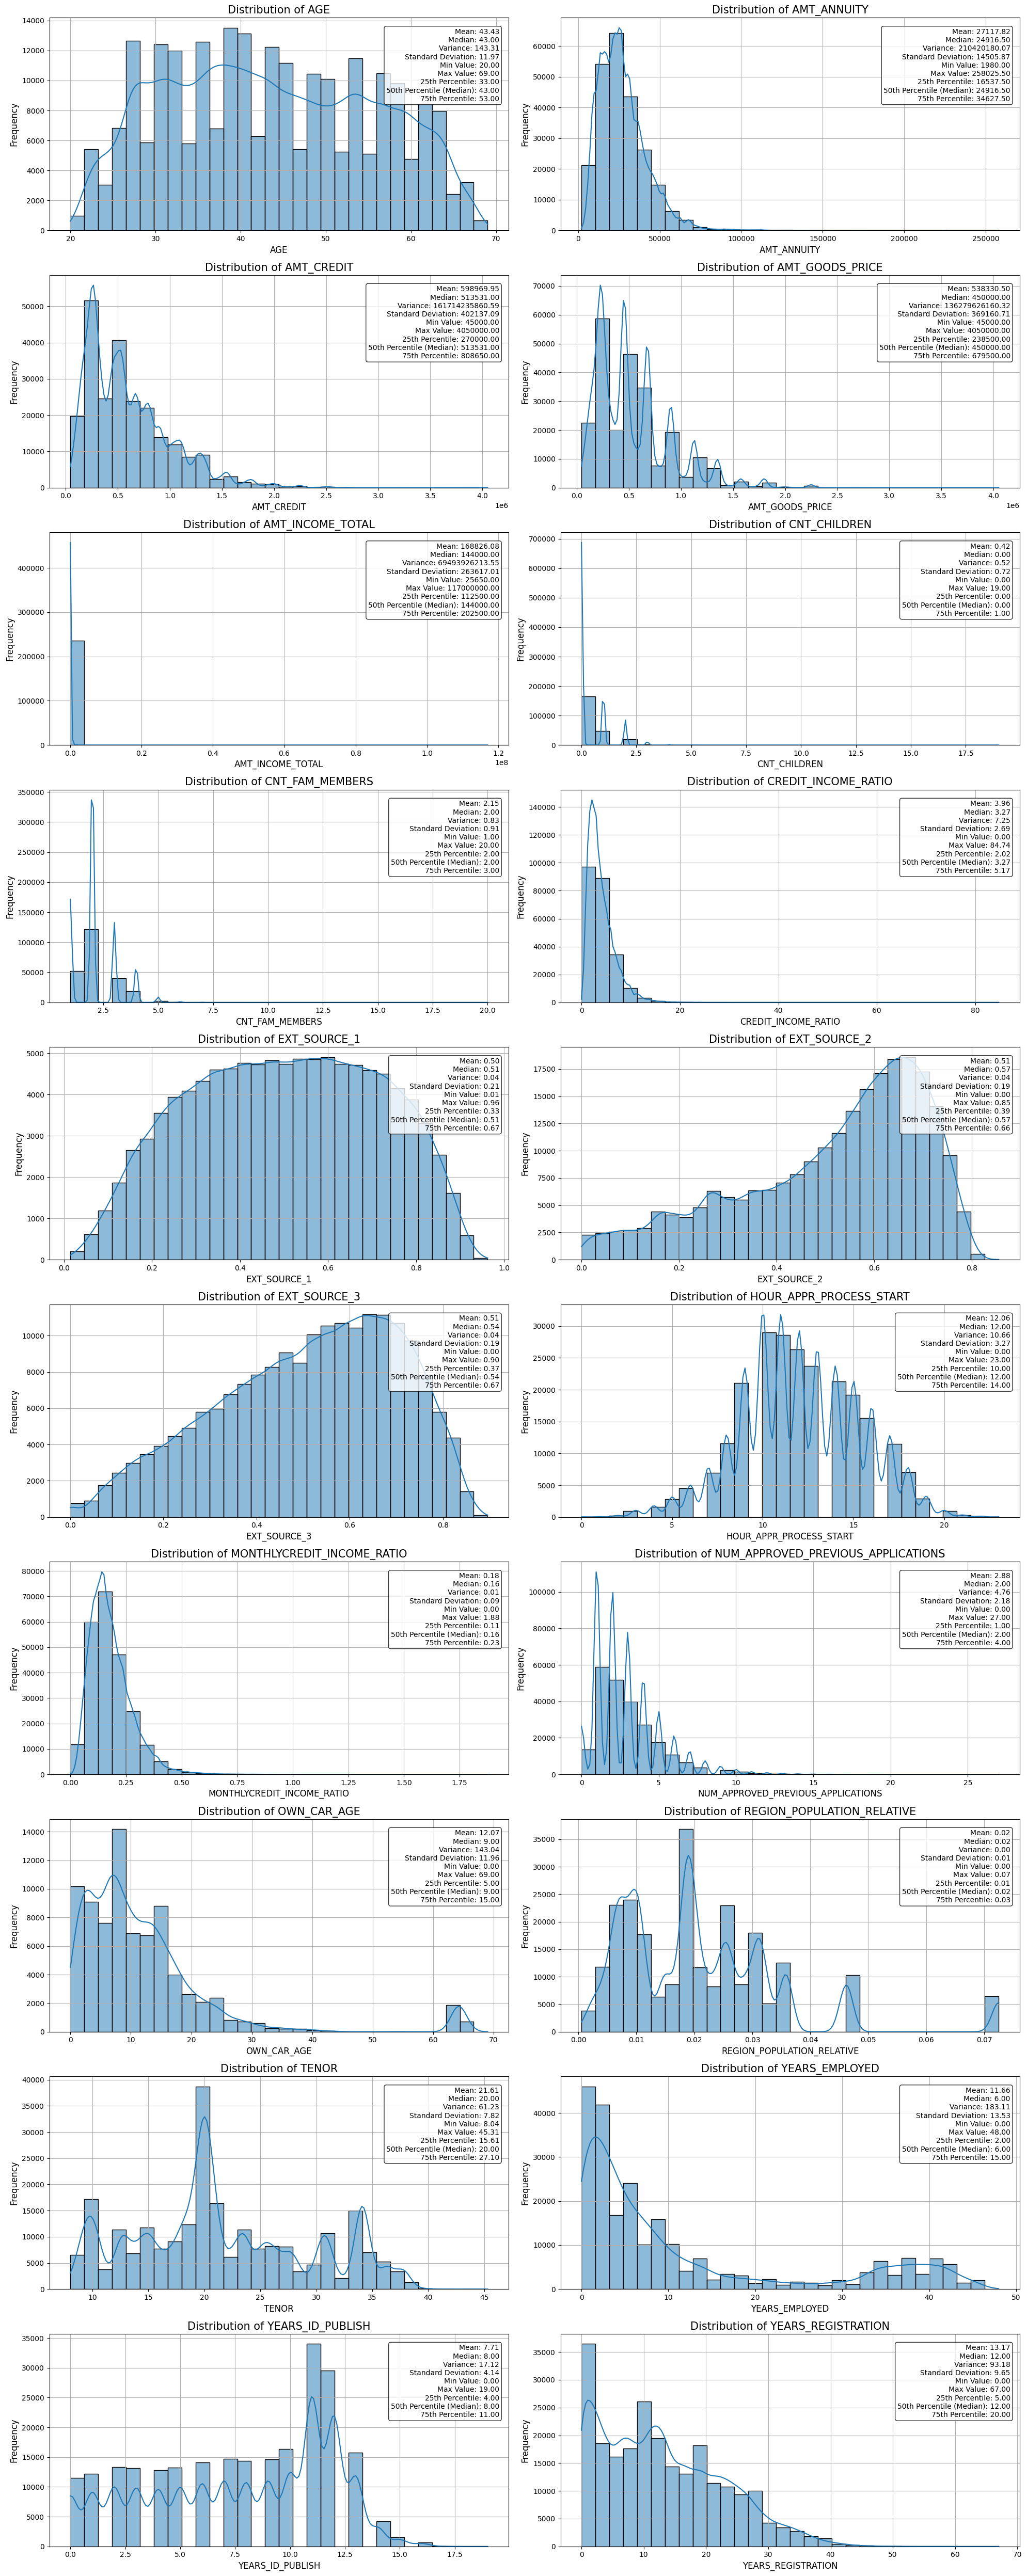

In [368]:
# Select the reasonable numeric columns excluding binary columns
selected_columns = [
    'EXT_SOURCE_1', 'EXT_SOURCE_3', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 
    'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'OWN_CAR_AGE', 'CNT_FAM_MEMBERS', 
    'HOUR_APPR_PROCESS_START', 'EXT_SOURCE_2', 'AGE', 'YEARS_EMPLOYED', 
    'YEARS_REGISTRATION', 'YEARS_ID_PUBLISH', 'CREDIT_INCOME_RATIO', 'MONTHLYCREDIT_INCOME_RATIO', 'TENOR', 
    'NUM_APPROVED_PREVIOUS_APPLICATIONS'
]
# Sort the selected columns alphabetically
selected_columns_sorted = sorted(selected_columns)

# Set up the number of rows and columns for subplots
num_cols = 2  # Two plots per row
num_rows = (len(selected_columns_sorted) + 1) // num_cols  # Calculate the required number of rows

# Create the figure and axes for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))
axes = axes.flatten()  # Flatten the axes for easy iteration

# Loop through each column and plot the charts
for i, col in enumerate(selected_columns_sorted):
    # Calculate basic statistics
    mean = cur_app[col].mean()
    median = cur_app[col].median()
    variance = cur_app[col].var()
    std_dev = cur_app[col].std()
    quantiles = cur_app[col].quantile([0.25, 0.5, 0.75])
    min_value = cur_app[col].min()
    max_value = cur_app[col].max()

    # Plot histogram for each column
    sns.histplot(cur_app[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].grid(True)

    # Add statistical information as text on the plot
    textstr = (
        f'Mean: {mean:.2f}\n'
        f'Median: {median:.2f}\n'
        f'Variance: {variance:.2f}\n'
        f'Standard Deviation: {std_dev:.2f}\n'
        f'Min Value: {min_value:.2f}\n'
        f'Max Value: {max_value:.2f}\n'
        f'25th Percentile: {quantiles[0.25]:.2f}\n'
        f'50th Percentile (Median): {quantiles[0.5]:.2f}\n'
        f'75th Percentile: {quantiles[0.75]:.2f}'
    )
    axes[i].text(
        0.98, 0.95, textstr, transform=axes[i].transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust the layout
plt.tight_layout()
plt.show()


In [369]:
# Select all categorical columns
categorical_columns = cur_app.select_dtypes(include=['object']).columns

# Initialize a list to store gap information for each categorical column
gap_info = []

# Iterate over each categorical column to calculate the default rate gap
for column in categorical_columns:
    default_rates = cur_app.groupby(column)['TARGET'].mean() * 100
    max_default = default_rates.max()
    min_default = default_rates.min()
    gap = max_default - min_default
    unique_values = cur_app[column].nunique()  # Get number of unique values for each column
    gap_info.append({
        'Column': column,
        'Gap': gap,
        'Unique Values': unique_values,
        'Highest Default Rate': max_default,
        'Lowest Default Rate': min_default
    })

# Convert the list to a DataFrame and sort by the gap in descending order
gap_df = pd.DataFrame(gap_info).sort_values(by='Gap', ascending=False)

# Display the result
print(gap_df)

                        Column        Gap  Unique Values  \
5             NAME_INCOME_TYPE  36.842105              8   
9              OCCUPATION_TYPE  12.385639             19   
11           ORGANIZATION_TYPE  11.487303             58   
1                  CODE_GENDER  10.213509              3   
7           NAME_FAMILY_STATUS  10.032476              6   
6          NAME_EDUCATION_TYPE   8.809075              5   
12            EMPLOYMENT_GROUP   8.116299              7   
15                   AGE_GROUP   7.034364              9   
8            NAME_HOUSING_TYPE   5.506494              6   
13              CHILDREN_GROUP   4.230037              4   
17      YEARS_ID_PUBLISH_GROUP   4.036777              7   
16    YEARS_REGISTRATION_GROUP   3.439103              8   
18                PREAPP_GROUP   3.096548              7   
0           NAME_CONTRACT_TYPE   2.837769              2   
14                INCOME_GROUP   2.474310              5   
4              NAME_TYPE_SUITE   1.91457

In [370]:
cur_app['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    52410
XNA                       42513
Self-employed             29340
Other                     12806
Medicine                   8646
Business Entity Type 2     8122
Government                 7984
School                     6875
Trade: type 7              5978
Kindergarten               5270
Construction               5074
Business Entity Type 1     4556
Transport: type 4          4092
Trade: type 3              2657
Industry: type 9           2566
Security                   2521
Industry: type 3           2494
Housing                    2258
Industry: type 11          2072
Military                   2053
Bank                       1929
Agriculture                1899
Police                     1808
Transport: type 2          1720
Postal                     1695
Security Ministries        1547
Trade: type 2              1456
Restaurant                 1413
Services                   1218
University                 1035
Industry: type 7      

C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\2752787226.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cur_app, x='ORGANIZATION_TYPE', palette='Set3')


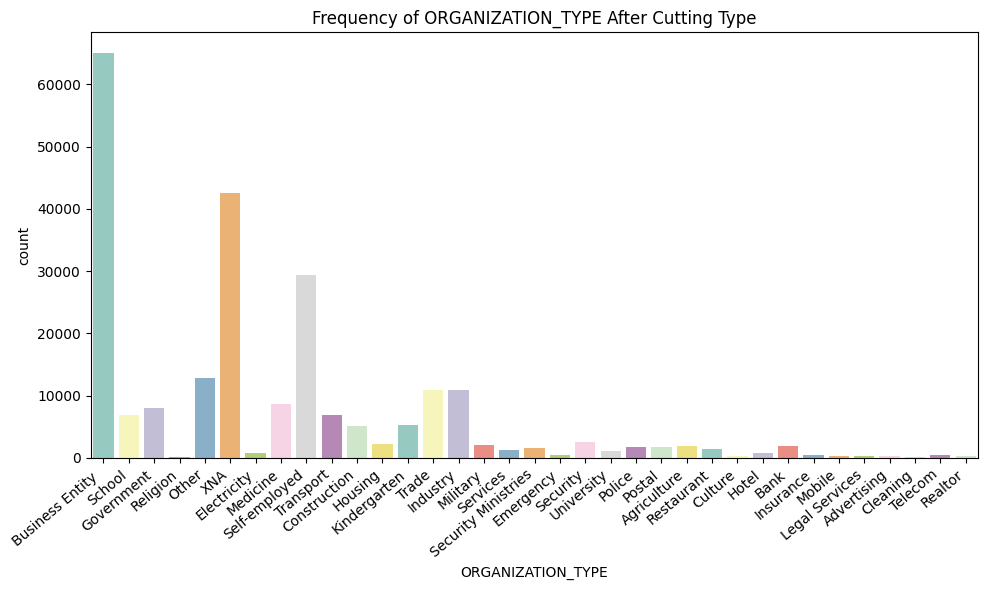

In [371]:
#Merge all of different type (...: type ...) in ORGANIZATION_TYPE in once for better visualization
cur_app['ORGANIZATION_TYPE'] = cur_app['ORGANIZATION_TYPE'].apply(lambda x: x.split(': type')[0] if ': type' in str(x) else (x.split('Type')[0] if 'Type' in str(x) else x))
plt.figure(figsize=(10, 6))
sns.countplot(data=cur_app, x='ORGANIZATION_TYPE', palette='Set3')
plt.title('Frequency of ORGANIZATION_TYPE After Cutting Type')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

In [372]:
# Select all categorical columns
categorical_columns = cur_app.select_dtypes(include=['object']).columns

# Initialize a list to store gap information for each categorical column
gap_info = []

# Iterate over each categorical column to calculate the default rate gap
for column in categorical_columns:
    default_rates = cur_app.groupby(column)['TARGET'].mean() * 100
    max_default = default_rates.max()
    min_default = default_rates.min()
    gap = max_default - min_default
    unique_values = cur_app[column].nunique()  # Get number of unique values for each column
    gap_info.append({
        'Column': column,
        'Gap': gap,
        'Unique Values': unique_values,
        'Highest Default Rate': max_default,
        'Lowest Default Rate': min_default
    })

# Convert the list to a DataFrame and sort by the gap in descending order
gap_df = pd.DataFrame(gap_info).sort_values(by='Gap', ascending=False)

# Display the result
print(gap_df)

                        Column        Gap  Unique Values  \
5             NAME_INCOME_TYPE  36.842105              8   
9              OCCUPATION_TYPE  12.385639             19   
1                  CODE_GENDER  10.213509              3   
7           NAME_FAMILY_STATUS  10.032476              6   
6          NAME_EDUCATION_TYPE   8.809075              5   
12            EMPLOYMENT_GROUP   8.116299              7   
11           ORGANIZATION_TYPE   7.439614             35   
15                   AGE_GROUP   7.034364              9   
8            NAME_HOUSING_TYPE   5.506494              6   
13              CHILDREN_GROUP   4.230037              4   
17      YEARS_ID_PUBLISH_GROUP   4.036777              7   
16    YEARS_REGISTRATION_GROUP   3.439103              8   
18                PREAPP_GROUP   3.096548              7   
0           NAME_CONTRACT_TYPE   2.837769              2   
14                INCOME_GROUP   2.474310              5   
4              NAME_TYPE_SUITE   1.91457

In [373]:
# Categorize OCCUPATION_TYPE into broader groups for easier EDA
occupation_map = {
    'Laborers': 'Labor',
    'Low-skill Laborers': 'Labor',
    'Cleaning staff': 'Service',
    'Cooking staff': 'Service',
    'Security staff': 'Service',
    'Waiters/barmen staff': 'Service',
    'Private service staff': 'Service',
    'Managers': 'Management',
    'Core staff': 'Management',
    'High skill tech staff': 'Technical',
    'IT staff': 'Technical',
    'Medicine staff': 'Medical',
    'Accountants': 'Finance',
    'Sales staff': 'Sales',
    'Secretaries': 'Administrative',
    'Realty agents': 'Sales',
    'HR staff': 'Administrative',
    'Other': 'Other'
}
cur_app['OCCUPATION_GROUP'] = cur_app['OCCUPATION_TYPE'].map(occupation_map).fillna('Other')

# Check the value counts for each group
print(cur_app['OCCUPATION_GROUP'].value_counts())

OCCUPATION_GROUP
Other             88380
Labor             44079
Management        37572
Sales             25049
Service           16423
Technical          9093
Finance            7553
Medical            6612
Administrative     1414
Name: count, dtype: int64


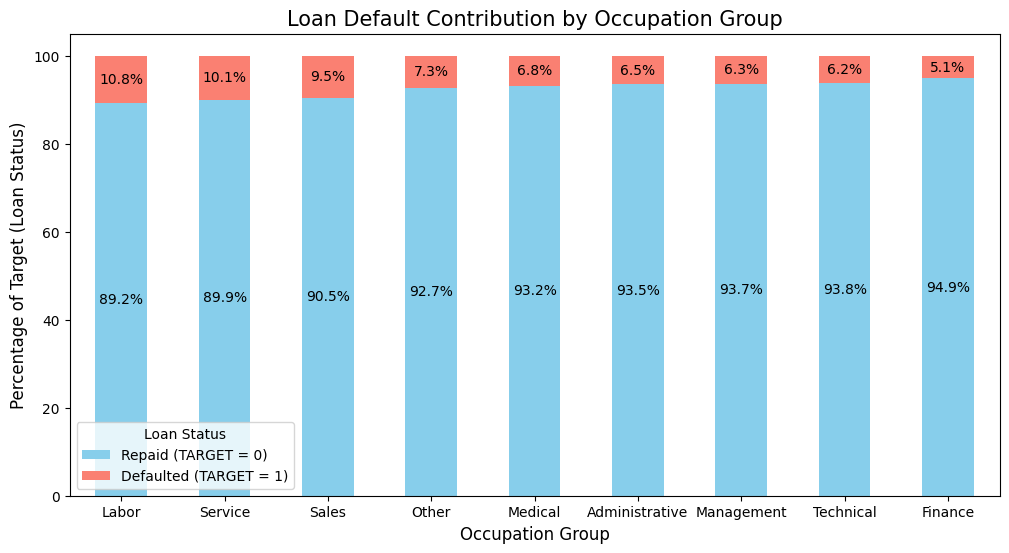

In [374]:
# Calculate the proportion of TARGET values for each education type
occupation_target = cur_app.groupby(['OCCUPATION_GROUP', 'TARGET']).size().unstack()
occupation_target_percentage = occupation_target.div(occupation_target.sum(axis=1), axis=0) * 100

# Sort by the share of defaults (TARGET = 1)
occupation_target_percentage_sorted = occupation_target_percentage.sort_values(by=1, ascending=False)


# Plot the 100% stacked column chart
label_ocu_tar = occupation_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])

# Add labels and title
plt.title('Loan Default Contribution by Occupation Group', fontsize=15)
plt.xlabel('Occupation Group', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_ocu_tar.containers:
    label_ocu_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)
   

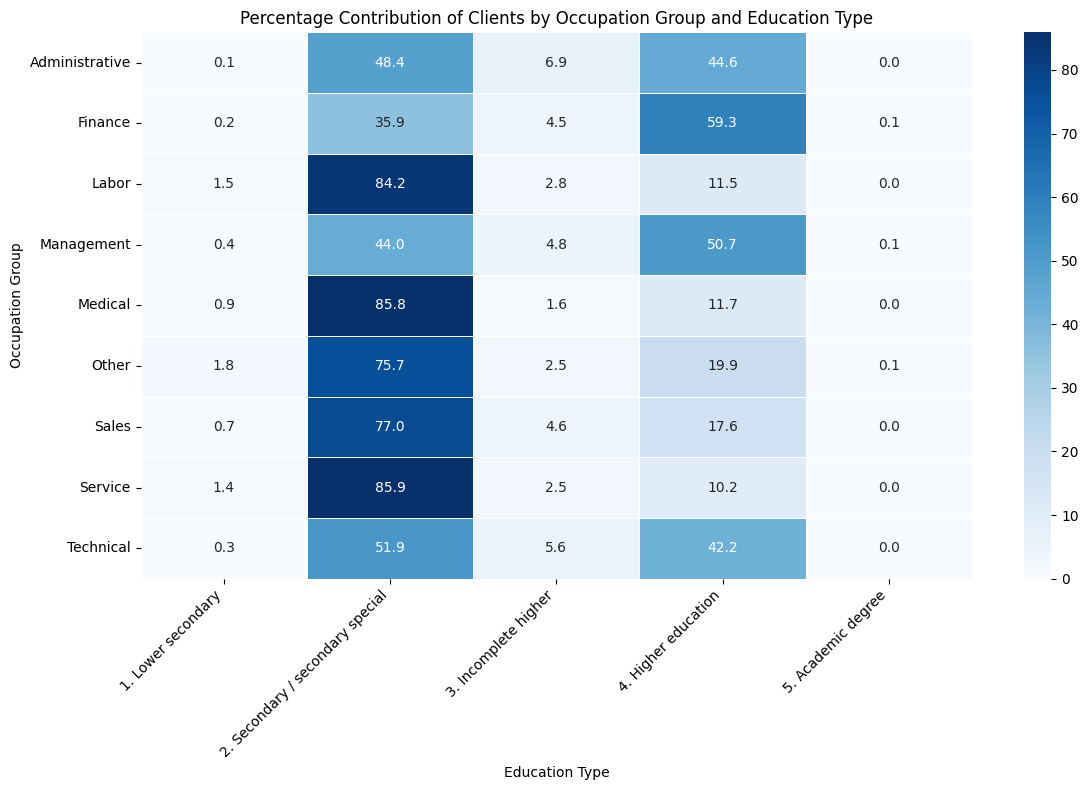

In [375]:
# Create the cross-tabulation table to calculate the share of clients between OCCUPATION_GROUP and NAME_EDUCATION_TYPE
occupation_education_crosstab = pd.crosstab(cur_app['OCCUPATION_GROUP'], cur_app['NAME_EDUCATION_TYPE'], normalize='index') * 100

# To visualize this as a heatmap to better understand the share of clients:
plt.figure(figsize=(12, 8))
sns.heatmap(occupation_education_crosstab, annot=True, fmt=".1f", cmap='Blues', linewidths=0.5)
plt.title('Percentage Contribution of Clients by Occupation Group and Education Type')
plt.xlabel('Education Type')
plt.ylabel('Occupation Group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

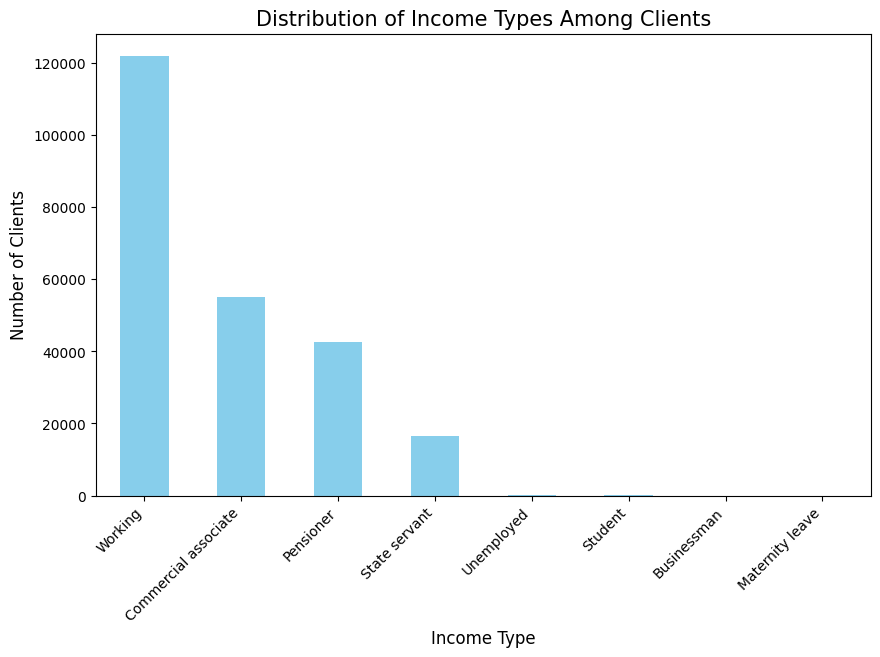

In [376]:
# Count the number of clients by income type
education_counts = cur_app['NAME_INCOME_TYPE'].value_counts()

# Plot the bar chart to show the share of Income types
plt.figure(figsize=(10, 6))
education_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Income Types Among Clients', fontsize=15)
plt.xlabel('Income Type', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

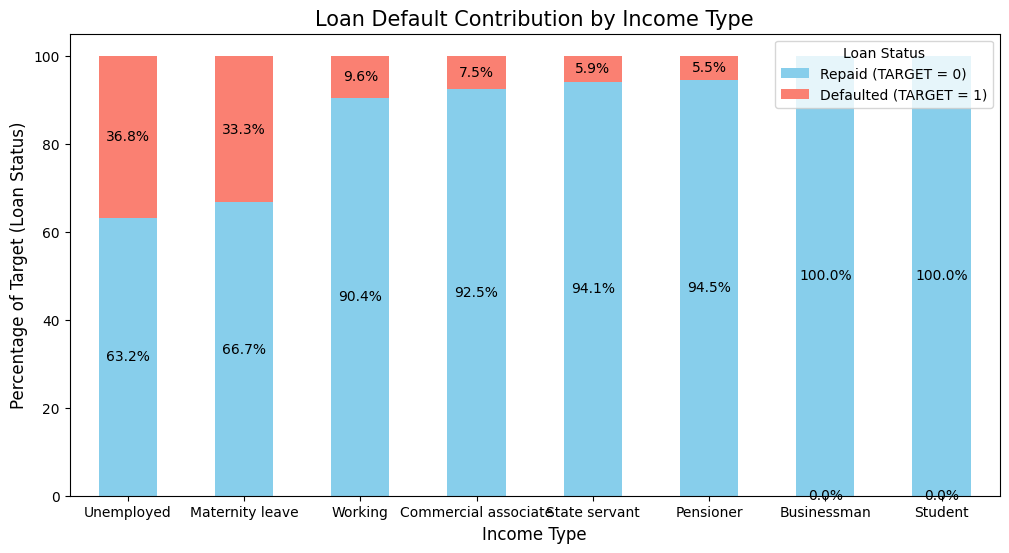

In [377]:
# Calculate the proportion of TARGET values for each income type
income_target = cur_app.groupby(['NAME_INCOME_TYPE', 'TARGET']).size().unstack()
income_target_percentage = income_target.div(income_target.sum(axis=1), axis=0) * 100


# Sort by the share of defaults (TARGET = 1)
income_target_percentage_sorted = income_target_percentage.sort_values(by=1, ascending=False)

# Plot the 100% stacked column chart
label_inc_tar = income_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])

# Add labels and title
plt.title('Loan Default Contribution by Income Type', fontsize=15)
plt.xlabel('Income Type', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_inc_tar.containers:
    label_inc_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)
   

In [378]:
# Check the number of values in Income Type
income_target

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,8.0,NaN
Commercial associate,50815.0,4133.0
Maternity leave,2.0,1.0
Pensioner,40183.0,2319.0
State servant,15666.0,985.0
Student,14.0,NaN
Unemployed,12.0,7.0
Working,110332.0,11698.0


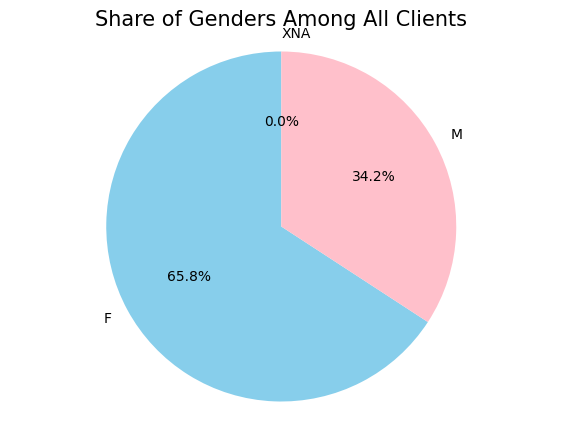

In [379]:
# Count the number of males and females
gender_counts = cur_app['CODE_GENDER'].value_counts()

# Plot a pie chart to show the share of genders among all clients
plt.figure(figsize=(7, 5))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['skyblue', 'pink'], startangle=90 )
plt.title('Share of Genders Among All Clients', fontsize=15)
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()

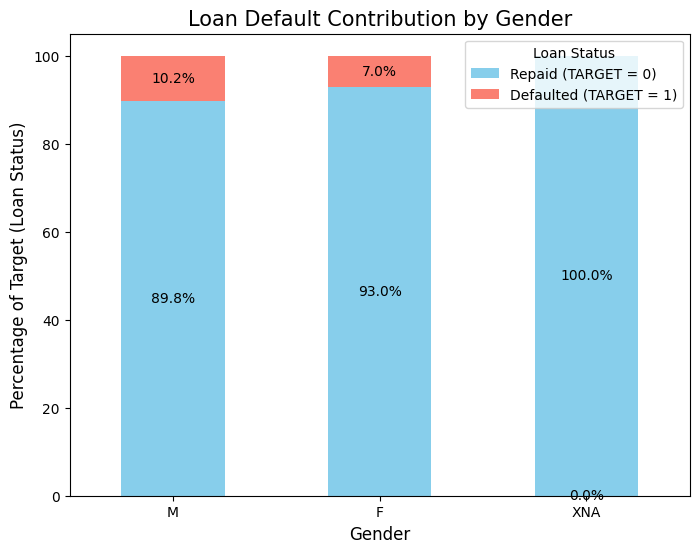

In [380]:
# Calculate the proportion of TARGET values for each gender
gender_target = cur_app.groupby(['CODE_GENDER', 'TARGET']).size().unstack()
gender_target_percentage = gender_target.div(gender_target.sum(axis=1), axis=0) * 100

# Sort by the share of defaults (TARGET = 1)
gender_target_percentage_sorted = gender_target_percentage.sort_values(by=1, ascending=False)

# Plot the 100% stacked column chart
label_gen_tar = gender_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(8, 6), color=['skyblue', 'salmon'])

# Add labels and title
plt.title('Loan Default Contribution by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_gen_tar.containers:
    label_gen_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)


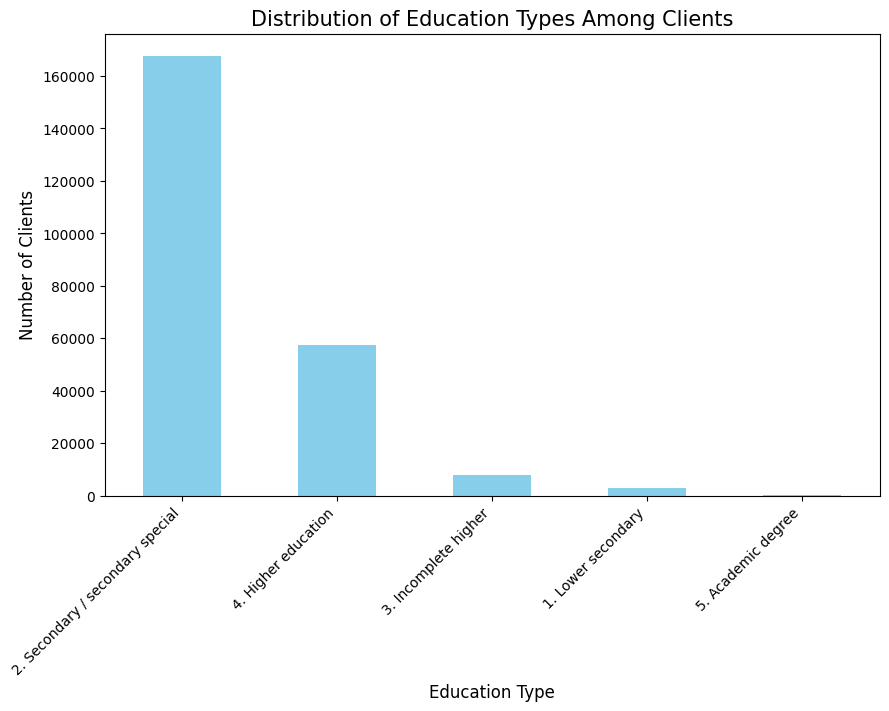

In [381]:
# Count the number of clients by education type
education_counts = cur_app['NAME_EDUCATION_TYPE'].value_counts()

# Plot the bar chart to show the share of different education types
plt.figure(figsize=(10, 6))
education_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Education Types Among Clients', fontsize=15)
plt.xlabel('Education Type', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

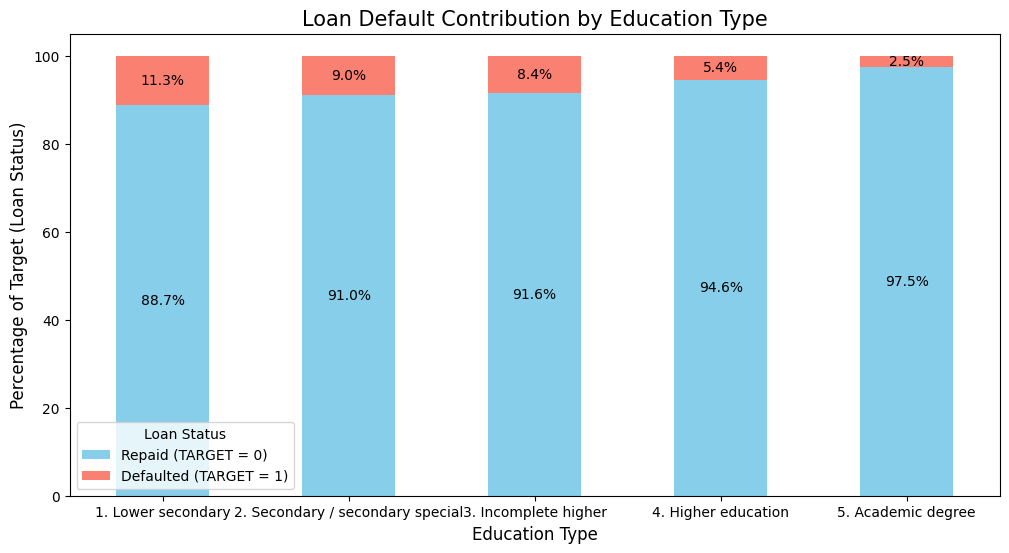

In [382]:
# Calculate the proportion of TARGET values for each education type
education_target = cur_app.groupby(['NAME_EDUCATION_TYPE', 'TARGET']).size().unstack()
education_target_percentage = education_target.div(education_target.sum(axis=1), axis=0) * 100

# Sort by the share of defaults (TARGET = 1)
education_target_percentage_sorted = education_target_percentage.sort_values(by=1, ascending=False)


# Plot the 100% stacked column chart
label_edu_tar = education_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])

# Add labels and title
plt.title('Loan Default Contribution by Education Type', fontsize=15)
plt.xlabel('Education Type', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_edu_tar.containers:
    label_edu_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)
   

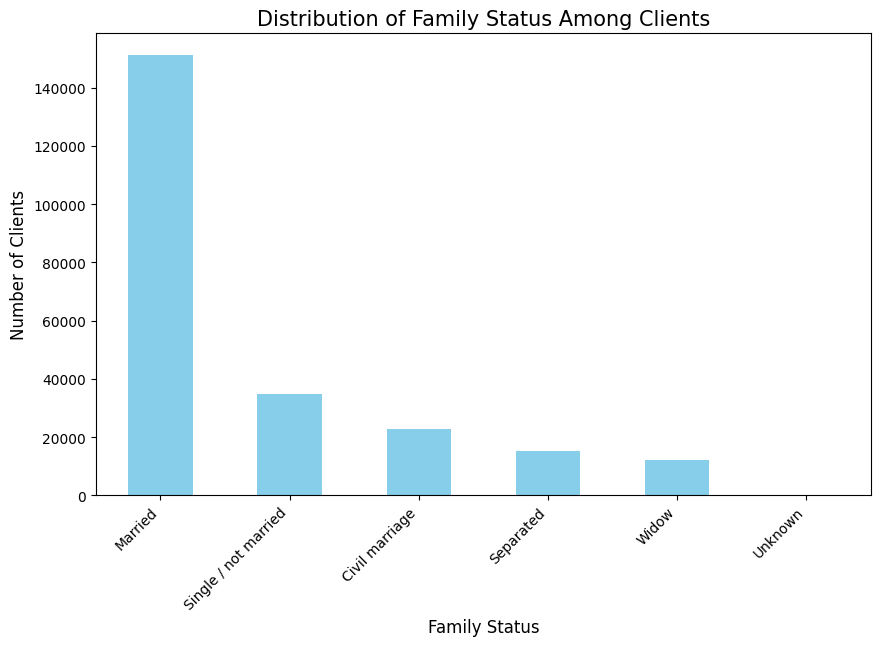

In [383]:
# Count the number of clients by education type
family_status_counts = cur_app['NAME_FAMILY_STATUS'].value_counts()

# Plot the bar chart to show the share of different education types
plt.figure(figsize=(10, 6))
family_status_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Family Status Among Clients', fontsize=15)
plt.xlabel('Family Status', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

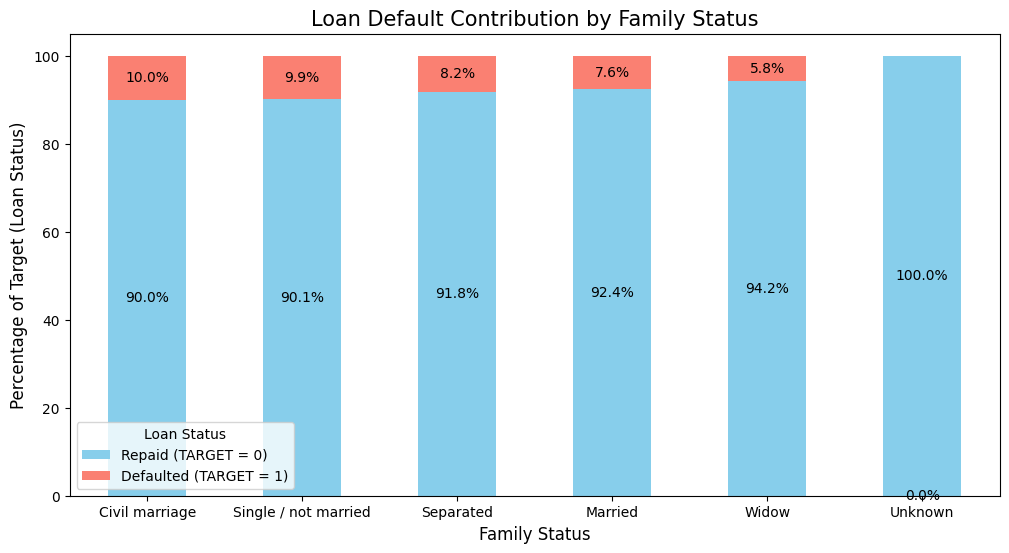

In [384]:
# Calculate the proportion of TARGET values for each education type
familystatus_target = cur_app.groupby(['NAME_FAMILY_STATUS', 'TARGET']).size().unstack()
familystatus_target_percentage = familystatus_target.div(familystatus_target.sum(axis=1), axis=0) * 100

# Sort by the share of defaults (TARGET = 1)
familystatus_target_percentage_sorted = familystatus_target_percentage.sort_values(by=1, ascending=False)


# Plot the 100% stacked column chart
label_fam_tar = familystatus_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])

# Add labels and title
plt.title('Loan Default Contribution by Family Status', fontsize=15)
plt.xlabel('Family Status', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_fam_tar.containers:
    label_fam_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

plt.show()

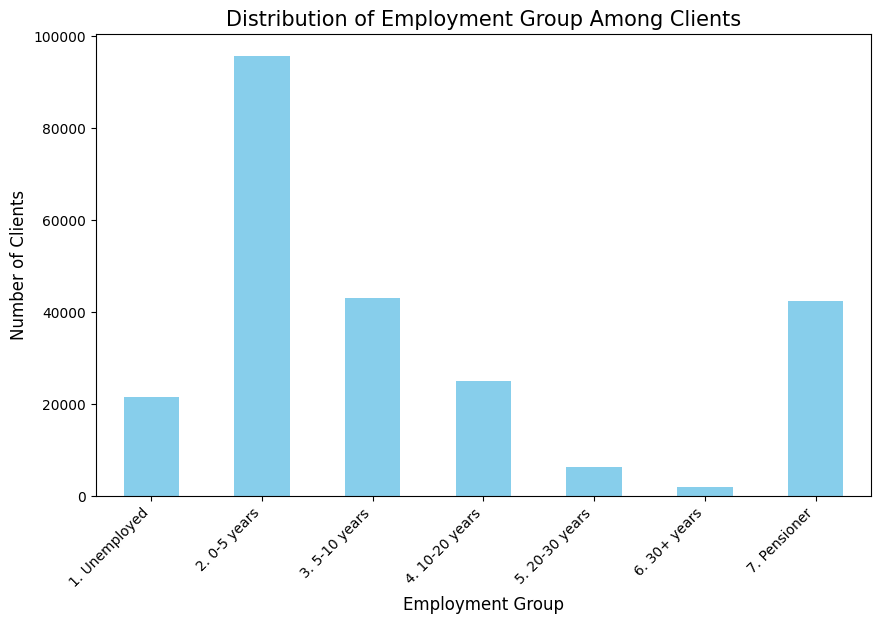

In [385]:
# Count the number of clients by employment group
employment_group_counts = cur_app['EMPLOYMENT_GROUP'].value_counts()
# Sort the index alphabetically
employment_group_counts_sorted = employment_group_counts.sort_index()

# Plot the bar chart to show the share of employment group
plt.figure(figsize=(10, 6))
employment_group_counts_sorted.plot(kind='bar', color='skyblue')
plt.title('Distribution of Employment Group Among Clients', fontsize=15)
plt.xlabel('Employment Group', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

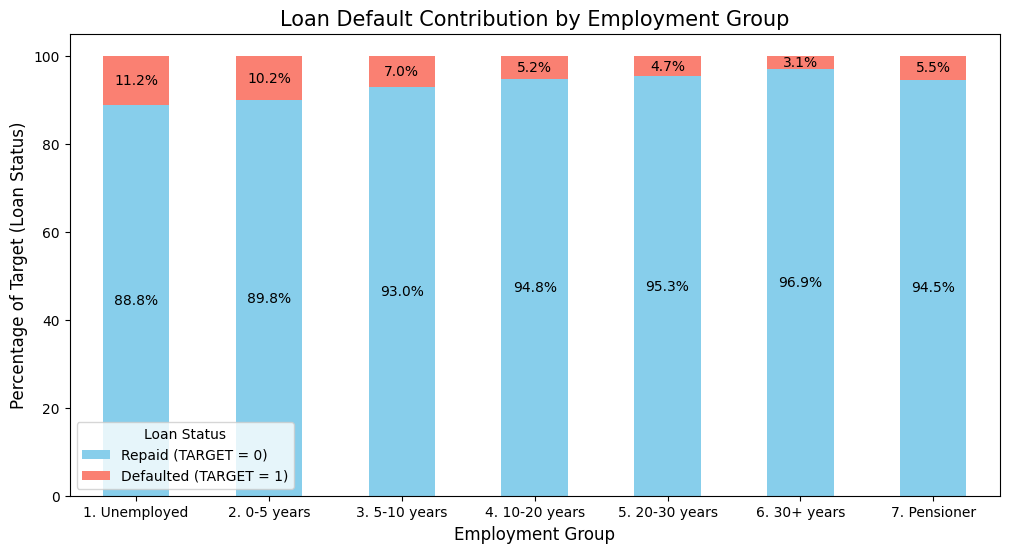

In [386]:
# Calculate the proportion of TARGET values for each education type
employment_group_target = cur_app.groupby(['EMPLOYMENT_GROUP', 'TARGET']).size().unstack()
employment_group_target_percentage = employment_group_target.div(employment_group_target.sum(axis=1), axis=0) * 100
# Sort the index alphabetically
employment_group_target_percentage_sorted = employment_group_target_percentage.sort_index()

# Plot the 100% stacked column chart
label_emp_tar = employment_group_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])

# Add labels and title
plt.title('Loan Default Contribution by Employment Group', fontsize=15)
plt.xlabel('Employment Group', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_emp_tar.containers:
    label_emp_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)
   

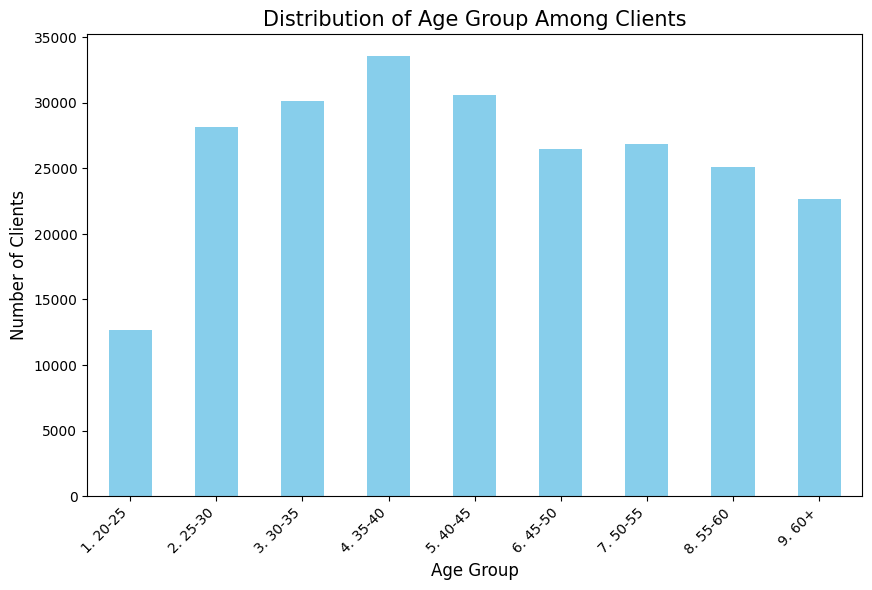

In [387]:
# Count the number of clients by age group
age_group_counts = cur_app['AGE_GROUP'].value_counts()
# Sort the index alphabetically
age_group_counts_sorted = age_group_counts.sort_index()

# Plot the bar chart to show the share of age group
plt.figure(figsize=(10, 6))
age_group_counts_sorted.plot(kind='bar', color='skyblue')
plt.title('Distribution of Age Group Among Clients', fontsize=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

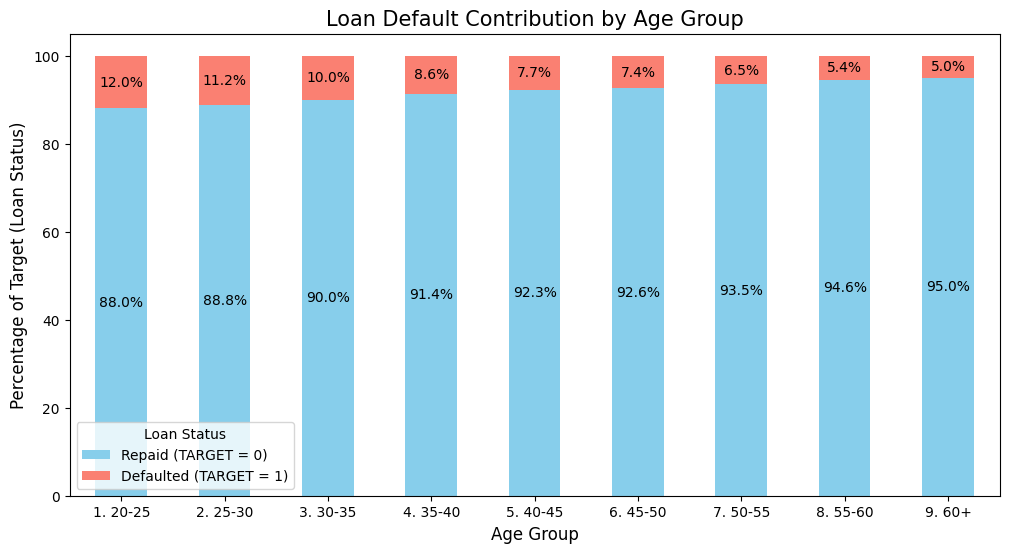

In [388]:
# Calculate the proportion of TARGET values for each education type
age_group_target = cur_app.groupby(['AGE_GROUP', 'TARGET']).size().unstack()
age_group_target_percentage = age_group_target.div(age_group_target.sum(axis=1), axis=0) * 100
# Sort the index alphabetically
age_group_target_percentage_sorted = age_group_target_percentage.sort_index()

# Plot the 100% stacked column chart
label_age_tar = age_group_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])

# Add labels and title
plt.title('Loan Default Contribution by Age Group', fontsize=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_age_tar.containers:
    label_age_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)
   

In [389]:
# List of FLAG_DOCUMENT columns
flag_document_columns = [col for col in cur_app.columns if 'FLAG_DOCUMENT' in col]

# Calculate default rates and number of clients who provided each document
document_info = []
for doc in flag_document_columns:
    document_target = cur_app.groupby(doc)['TARGET'].mean() * 100
    num_clients_provided = cur_app[doc].sum()  # Number of clients who provided the document
    document_info.append({
        'Document': doc,
        'Default Rate (Not Provided)': document_target.get(0, 0),
        'Default Rate (Provided)': document_target.get(1, 0),
        'Number of Clients Provided': num_clients_provided
    })

# Convert the list to a DataFrame
default_rate_df = pd.DataFrame(document_info).sort_values(by='Number of Clients Provided', ascending=False)

# Display the DataFrame
print(default_rate_df)

            Document  Default Rate (Not Provided)  Default Rate (Provided)  \
1    FLAG_DOCUMENT_3                     6.211080                 8.877895   
4    FLAG_DOCUMENT_6                     8.351558                 5.557158   
6    FLAG_DOCUMENT_8                     8.166388                 7.416093   
3    FLAG_DOCUMENT_5                     8.110060                 7.804196   
14  FLAG_DOCUMENT_16                     8.136312                 5.044510   
16  FLAG_DOCUMENT_18                     8.121086                 6.170886   
9   FLAG_DOCUMENT_11                     8.112324                 6.357759   
7    FLAG_DOCUMENT_9                     8.111555                 6.535948   
11  FLAG_DOCUMENT_13                     8.122440                 3.264813   
12  FLAG_DOCUMENT_14                     8.119965                 3.257790   
13  FLAG_DOCUMENT_15                     8.111729                 2.836879   
17  FLAG_DOCUMENT_19                     8.106001               

In [390]:
# Categorize TOTAL_DOCUMENTS_PROVIDED into bins for easier analysis
doc_bins = [-1, 0, 1, 2, float('inf')]
doc_labels = ['0 Document', '1 Document', '2 Documents', 'More than 2 Documents']
cur_app['DOCUMENTS_PROVIDED_GROUP'] = pd.cut(cur_app['TOTAL_DOCUMENTS_PROVIDED'], bins=doc_bins, labels=doc_labels)

# Check numbers after categorizing
cur_app['DOCUMENTS_PROVIDED_GROUP'].value_counts()


DOCUMENTS_PROVIDED_GROUP
1 Document               207466
0 Document                22638
2 Documents                5952
More than 2 Documents       119
Name: count, dtype: int64

C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\980158274.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  document_group_target = cur_app.groupby(['DOCUMENTS_PROVIDED_GROUP', 'TARGET']).size().unstack()


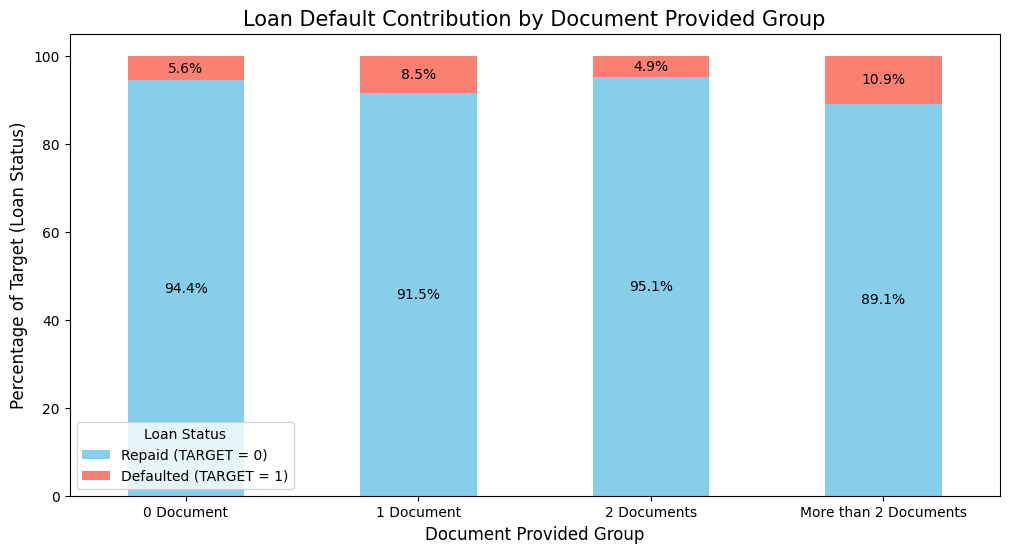

In [391]:
# Calculate the proportion of TARGET values for each education type
document_group_target = cur_app.groupby(['DOCUMENTS_PROVIDED_GROUP', 'TARGET']).size().unstack()
document_group_target_percentage = document_group_target.div(document_group_target.sum(axis=1), axis=0) * 100
# Sort the index alphabetically
document_group_target_percentage_sorted = document_group_target_percentage.sort_index()

# Plot the 100% stacked column chart
label_doc_tar = document_group_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])

# Add labels and title
plt.title('Loan Default Contribution by Document Provided Group', fontsize=15)
plt.xlabel('Document Provided Group', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_doc_tar.containers:
    label_doc_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)
   

In [392]:
# Append TOTAL_CONTACT_METHODS to contact_columns 
contact_columns.append('TOTAL_CONTACT_METHODS')

# Initialize a list to store gap information for each categorical column
gap_contact = []

# Iterate over each categorical column to calculate the default rate gap
for column in contact_columns:
    default_rates = cur_app.groupby(column)['TARGET'].mean() * 100
    max_default = default_rates.max()
    min_default = default_rates.min()
    gap = max_default - min_default
    unique_values = cur_app[column].nunique()  # Get number of unique values for each column
    gap_contact.append({
        'Column': column,
        'Gap': gap,
        'Unique Values': unique_values,
        'Highest Default Rate': max_default,
        'Lowest Default Rate': min_default
    })

# Convert the list to a DataFrame and sort by the gap in descending order
gap_contact_df = pd.DataFrame(gap_contact).sort_values(by='Gap', ascending=False)

# Display the result
print(gap_contact_df)

                  Column       Gap  Unique Values  Highest Default Rate  \
0             FLAG_MOBIL  8.105465              2              8.105465   
5  TOTAL_CONTACT_METHODS  3.365139              5              9.096859   
1         FLAG_EMP_PHONE  3.211285              2              8.683618   
2        FLAG_WORK_PHONE  1.859855              2              9.594629   
3             FLAG_PHONE  1.540319              2              8.538331   
4             FLAG_EMAIL  0.206168              2              8.117160   

   Lowest Default Rate  
0             0.000000  
5             5.731720  
1             5.472333  
2             7.734774  
3             6.998011  
4             7.910992  


In [393]:
# Count the number of 0 and 1 in FLAG_MOBIL
cur_app['FLAG_MOBIL'].value_counts()

FLAG_MOBIL
1    236174
0         1
Name: count, dtype: int64

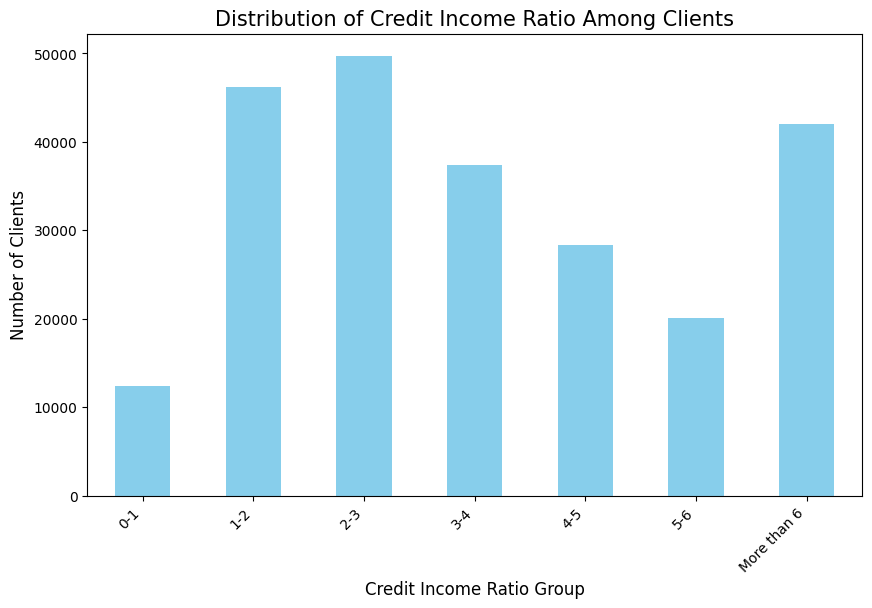

In [394]:
# Count the number of clients by credit income ratio group
credit_income_ratio_group_counts = cur_app['CREDIT_INCOME_RATIO_GROUP'].value_counts()
# Sort the index alphabetically
creidt_income_ratio_group_counts_sorted = credit_income_ratio_group_counts.sort_index()

# Plot the bar chart to show the share of credit income ratio  group
plt.figure(figsize=(10, 6))
creidt_income_ratio_group_counts_sorted.plot(kind='bar', color='skyblue')
plt.title('Distribution of Credit Income Ratio Among Clients', fontsize=15)
plt.xlabel('Credit Income Ratio Group', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\567342383.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_income_ratio_target = cur_app.groupby(['CREDIT_INCOME_RATIO_GROUP', 'TARGET']).size().unstack()


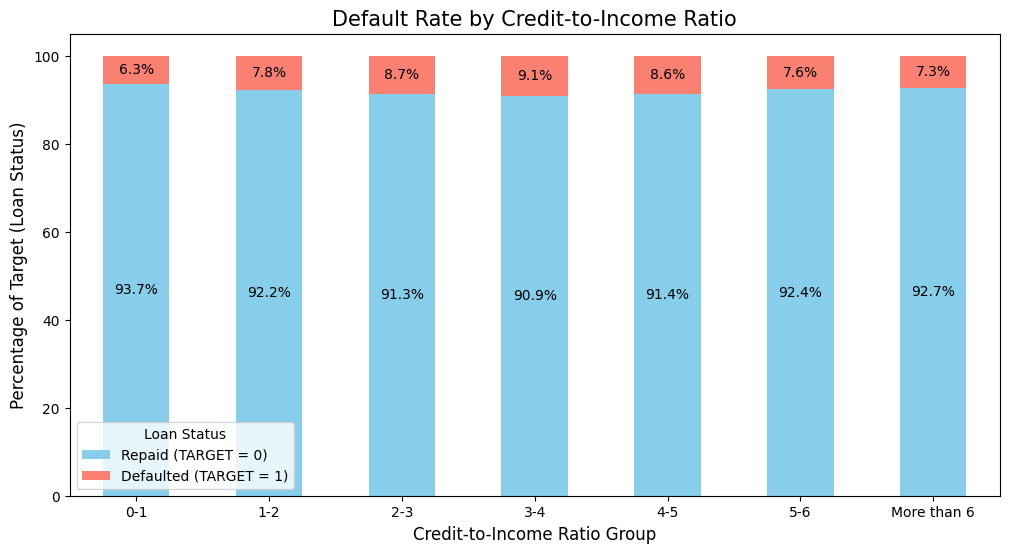

In [395]:
# Calculate the proportion of TARGET values for each ratio group
credit_income_ratio_target = cur_app.groupby(['CREDIT_INCOME_RATIO_GROUP', 'TARGET']).size().unstack()
credit_income_ratio_target_percentage = credit_income_ratio_target.div(credit_income_ratio_target.sum(axis=1), axis=0) * 100

# Sort the index alphabetically
credit_income_ratio_target_percentage_sorted = credit_income_ratio_target_percentage.sort_index()

# Plot the 100% stacked column chart
label_creinc_tar = credit_income_ratio_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])


# Add labels and title
plt.title('Default Rate by Credit-to-Income Ratio', fontsize=15)
plt.xlabel('Credit-to-Income Ratio Group', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_creinc_tar.containers:
    label_creinc_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)



C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\3545095658.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthlycredit_income_ratio_target = cur_app.groupby(['MONTHLYCREDIT_INCOME_RATIO_GROUP', 'TARGET']).size().unstack()


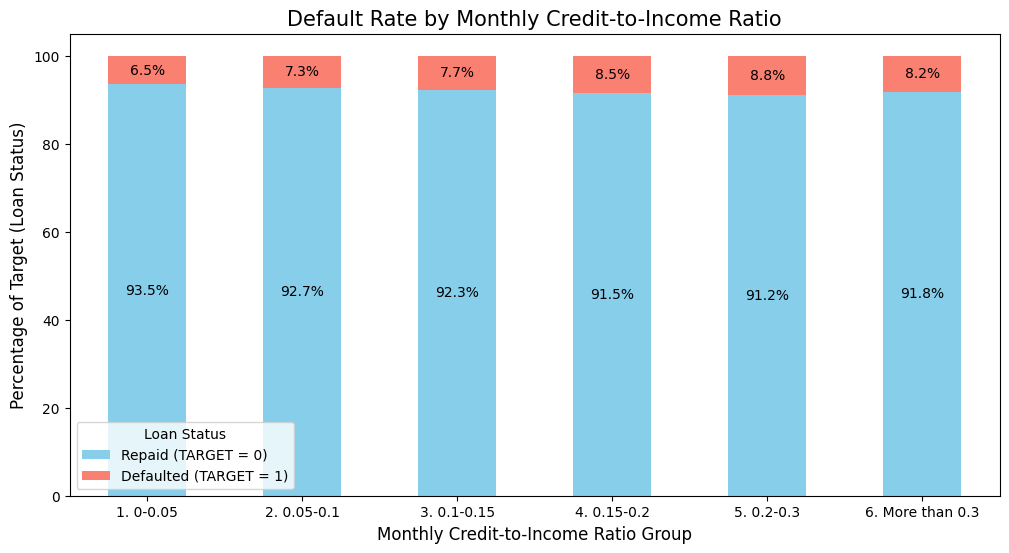

In [396]:
# Calculate the proportion of TARGET values for each ratio group
monthlycredit_income_ratio_target = cur_app.groupby(['MONTHLYCREDIT_INCOME_RATIO_GROUP', 'TARGET']).size().unstack()
monthlycredit_income_ratio_target_percentage = monthlycredit_income_ratio_target.div(monthlycredit_income_ratio_target.sum(axis=1), axis=0) * 100

# Sort the index alphabetically
monthlycredit_income_ratio_target_percentage_sorted = monthlycredit_income_ratio_target_percentage.sort_index()

# Plot the 100% stacked column chart
label_mcreinc_tar = monthlycredit_income_ratio_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])


# Add labels and title
plt.title('Default Rate by Monthly Credit-to-Income Ratio', fontsize=15)
plt.xlabel('Monthly Credit-to-Income Ratio Group', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_mcreinc_tar.containers:
    label_mcreinc_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)



C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\1691583810.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenorgroup_target = cur_app.groupby(['TENOR_GROUP', 'TARGET']).size().unstack()


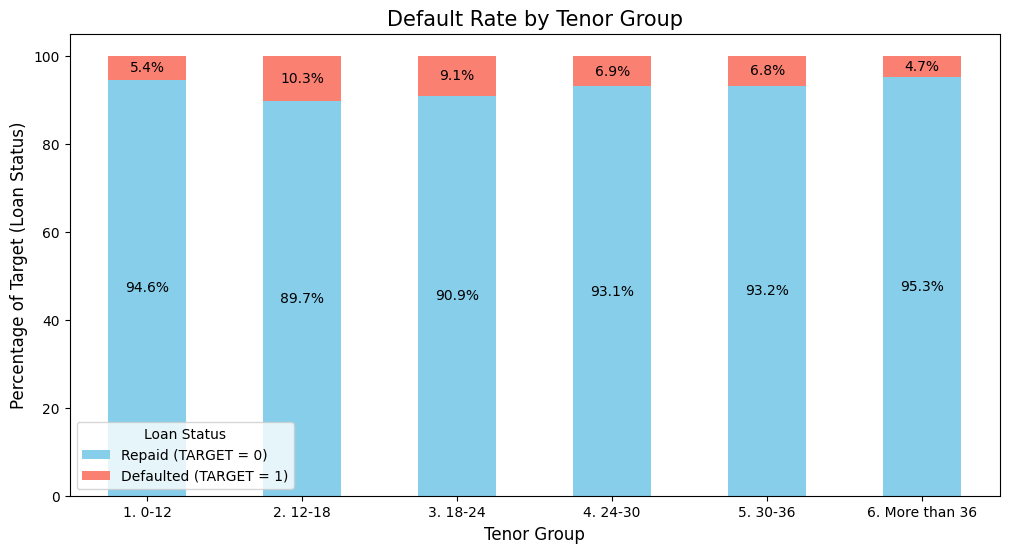

In [397]:
# Calculate the proportion of TARGET values for each ratio group
tenorgroup_target = cur_app.groupby(['TENOR_GROUP', 'TARGET']).size().unstack()
tenorgroup_target_percentage = tenorgroup_target.div(tenorgroup_target.sum(axis=1), axis=0) * 100

# Sort the index alphabetically
tenorgroup_target_percentage_sorted = tenorgroup_target_percentage.sort_index()

# Plot the 100% stacked column chart
label_ten_tar = tenorgroup_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])


# Add labels and title
plt.title('Default Rate by Tenor Group', fontsize=15)
plt.xlabel('Tenor Group', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_ten_tar.containers:
    label_ten_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)



In [398]:
average_annuity_by_tenor_group = cur_app.groupby('TENOR_GROUP')['AMT_ANNUITY'].mean().reset_index()

# Display the result
print(average_annuity_by_tenor_group)

       TENOR_GROUP   AMT_ANNUITY
0          1. 0-12  27486.828232
1         2. 12-18  26172.424927
2         3. 18-24  24705.039684
3         4. 24-30  30325.554305
4         5. 30-36  28743.756213
5  6. More than 36  35827.795272


C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\2393143006.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_annuity_by_tenor_group = cur_app.groupby('TENOR_GROUP')['AMT_ANNUITY'].mean().reset_index()


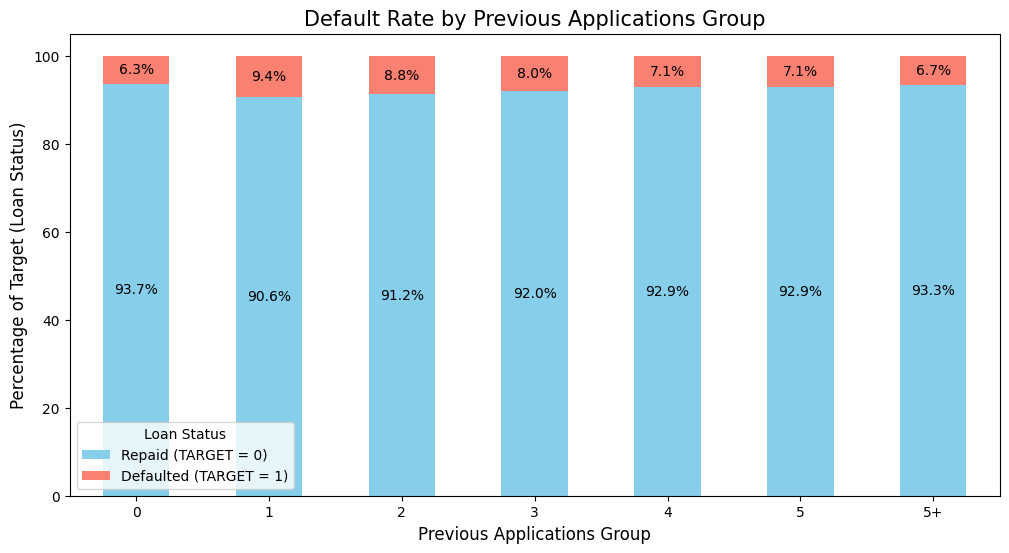

In [399]:
# Calculate the proportion of TARGET values for each ratio group
preappgroup_target = cur_app.groupby(['PREAPP_GROUP', 'TARGET']).size().unstack()
preappgroup_target_percentage = preappgroup_target.div(preappgroup_target.sum(axis=1), axis=0) * 100

# Sort the index alphabetically
preappgroup_target_percentage_sorted = preappgroup_target_percentage.sort_index()

# Plot the 100% stacked column chart
label_preapp_tar = preappgroup_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])


# Add labels and title
plt.title('Default Rate by Previous Applications Group', fontsize=15)
plt.xlabel('Previous Applications Group', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_preapp_tar.containers:
    label_preapp_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

In [400]:
# Add the columns having same characteristics to test in here is the checking between customer declare and reality
intergrity_columns = [
    'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
    'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'
]

# Initialize a list to store gap information for each categorical column
intergrity_info = []

# Iterate over each categorical column to calculate the default rate gap
for column in intergrity_columns:
    default_rates = cur_app.groupby(column)['TARGET'].mean() * 100
    max_default = default_rates.max()
    min_default = default_rates.min()
    gap = max_default - min_default
    unique_values = cur_app[column].nunique()  # Get number of unique values for each column
    intergrity_info.append({
        'Column': column,
        'Gap': gap,
        'Unique Values': unique_values,
        'Highest Default Rate': max_default,
        'Lowest Default Rate': min_default
    })

# Convert the list to a DataFrame and sort by the gap in descending order
intergrity_df = pd.DataFrame(intergrity_info).sort_values(by='Gap', ascending=False)

# Display the result
print(intergrity_df)


                        Column       Gap  Unique Values  Highest Default Rate  \
3       REG_CITY_NOT_LIVE_CITY  4.509315              2             12.261905   
4       REG_CITY_NOT_WORK_CITY  3.309405              2             10.651420   
5      LIVE_CITY_NOT_WORK_CITY  2.327820              2             10.015085   
0   REG_REGION_NOT_LIVE_REGION  1.335143              2              9.420290   
1   REG_REGION_NOT_WORK_REGION  0.879035              2              8.939709   
2  LIVE_REGION_NOT_WORK_REGION  0.464911              2              8.551465   

   Lowest Default Rate  
3             7.752590  
4             7.342015  
5             7.687265  
0             8.085147  
1             8.060674  
2             8.086554  


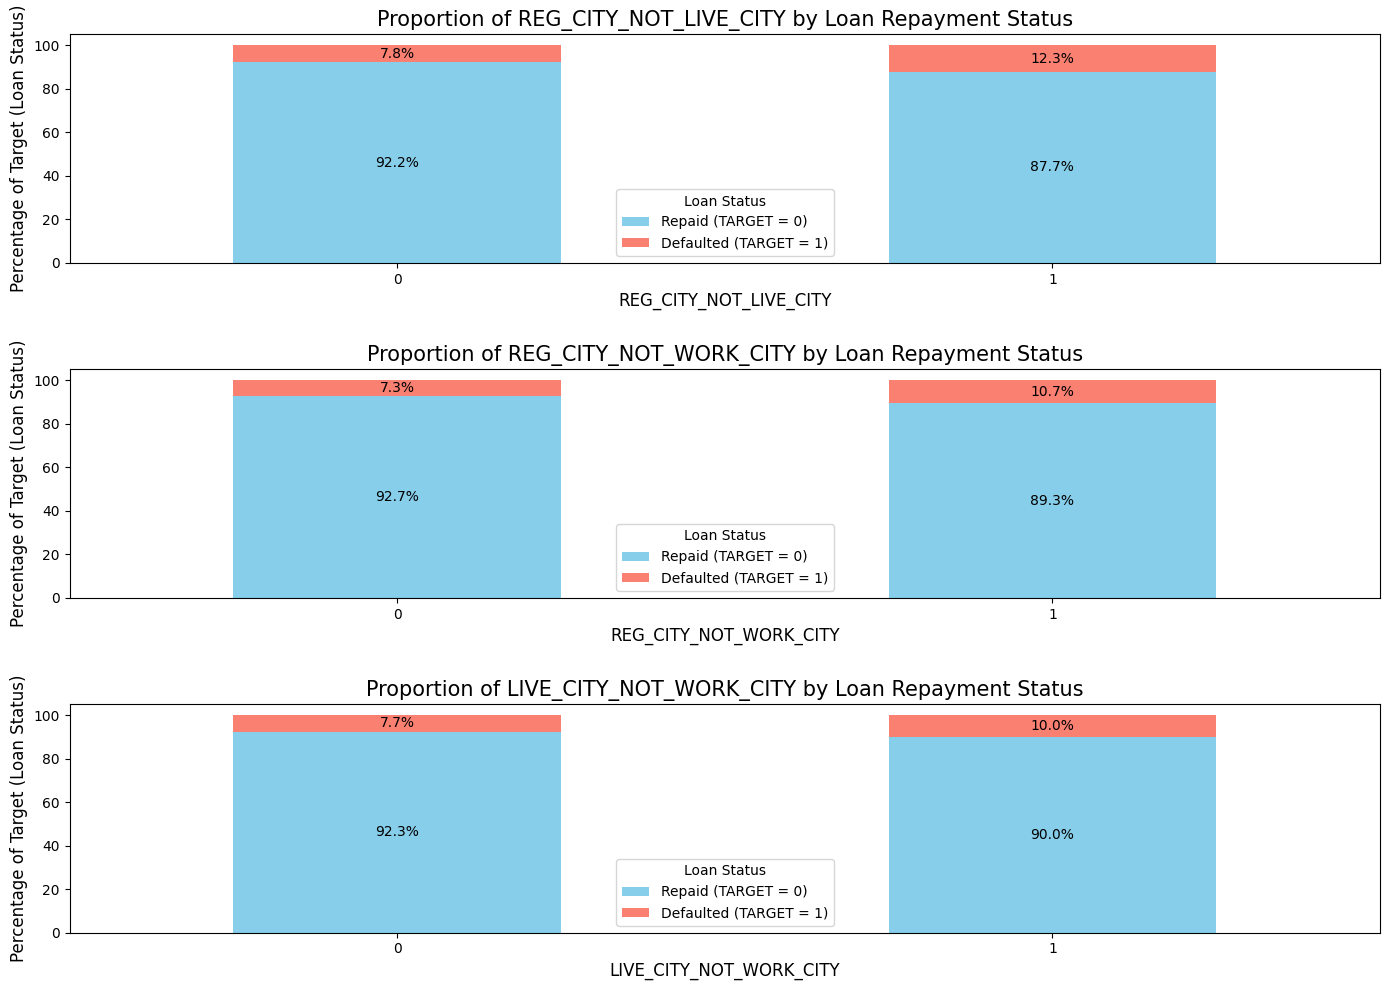

In [401]:
# Define the binary columns to be analyzed
binary_columns = ['REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY']

# Set up the figure size
plt.figure(figsize=(14, 10))

# Loop through each binary column to calculate the proportions and plot
for i, col in enumerate(binary_columns):
    # Calculate the proportion of TARGET values for each binary group
    col_target = cur_app.groupby([col, 'TARGET']).size().unstack()
    col_target_percentage = col_target.div(col_target.sum(axis=1), axis=0) * 100

    # Set up a subplot for each binary column
    plt.subplot(3, 1, i + 1)
    
    # Plot the 100% stacked bar chart
    label_col = col_target_percentage.plot(kind='bar', stacked=True, figsize=(14, 10), ax=plt.gca(), color=['skyblue', 'salmon'])

    # Add labels and title
    plt.title(f'Proportion of {col} by Loan Repayment Status', fontsize=15)
    plt.xlabel(f'{col}', fontsize=12)
    plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

    # Adding percentage data labels on bars 
    for container in label_col.containers:
        label_col.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

# Tight layout to enhance spacing between subplots
plt.tight_layout(h_pad=2.5)
plt.show()


In [402]:
# Add the columns having same characteristics to test in here is the checking between customer declare and reality
bureau_columns = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]

# Initialize a list to store gap information for each categorical column
bureau_info = []

# Iterate over each categorical column to calculate the default rate gap
for column in bureau_columns:
    default_rates = cur_app.groupby(column)['TARGET'].mean() * 100
    max_default = default_rates.max()
    min_default = default_rates.min()
    gap = max_default - min_default
    unique_values = cur_app[column].nunique()  # Get number of unique values for each column
    bureau_info.append({
        'Column': column,
        'Gap': gap,
        'Unique Values': unique_values,
        'Highest Default Rate': max_default,
        'Lowest Default Rate': min_default
    })

# Convert the list to a DataFrame and sort by the gap in descending order
bureau_df = pd.DataFrame(bureau_info).sort_values(by='Gap', ascending=False)

# Display the result
print(bureau_df)


                       Column         Gap  Unique Values  \
5  AMT_REQ_CREDIT_BUREAU_YEAR  100.000000             24   
4   AMT_REQ_CREDIT_BUREAU_QRT   25.925926              9   
2  AMT_REQ_CREDIT_BUREAU_WEEK   13.793103              9   
1   AMT_REQ_CREDIT_BUREAU_DAY   13.043478              9   
0  AMT_REQ_CREDIT_BUREAU_HOUR   11.764706              5   
3   AMT_REQ_CREDIT_BUREAU_MON    7.846262             22   

   Highest Default Rate  Lowest Default Rate  
5            100.000000                  0.0  
4             25.925926                  0.0  
2             13.793103                  0.0  
1             13.043478                  0.0  
0             11.764706                  0.0  
3              7.846262                  0.0  


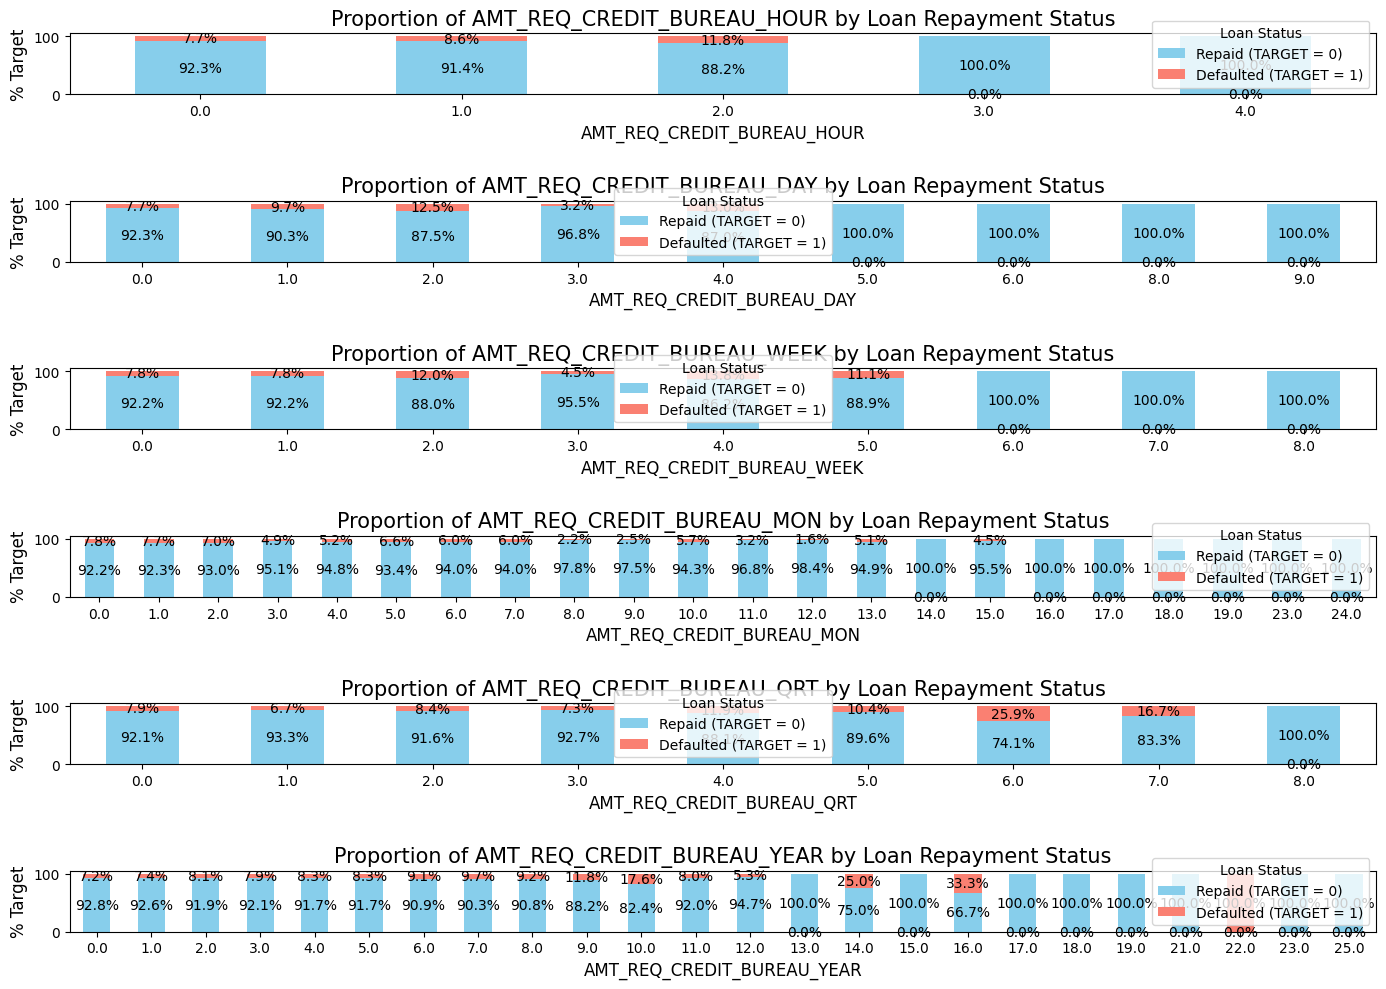

In [403]:
# Set up the figure size
plt.figure(figsize=(20, 10))

# Loop through each binary column to calculate the proportions and plot
for i, col in enumerate(bureau_columns):
    # Calculate the proportion of TARGET values for each binary group
    bureau_target = cur_app.groupby([col, 'TARGET']).size().unstack()
    bureau_target_percentage = bureau_target.div(bureau_target.sum(axis=1), axis=0) * 100

    # Set up a subplot for each binary column
    plt.subplot(6, 1, i + 1)
    
    # Plot the 100% stacked bar chart
    label_bureau_target = bureau_target_percentage.plot(kind='bar', stacked=True, figsize=(14, 10), ax=plt.gca(), color=['skyblue', 'salmon'])

    # Add labels and title
    plt.title(f'Proportion of {col} by Loan Repayment Status', fontsize=15)
    plt.xlabel(f'{col}', fontsize=12)
    plt.ylabel('% Target', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

    # Adding percentage data labels on bars 
    for container in label_bureau_target.containers:
        label_bureau_target.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

# Tight layout to enhance spacing between subplots
plt.tight_layout(h_pad=2.5)
plt.show()



In [404]:
# List of columns to sum
columns_to_sum = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]

# Create a new column with the sum of all specified columns
cur_app['TOTAL_CREDIT_BUREAU_REQUESTS'] = cur_app[columns_to_sum].sum(axis=1)

# Display the updated DataFrame with the new column
print(cur_app[['SK_ID_CURR', 'TOTAL_CREDIT_BUREAU_REQUESTS']].head())

   SK_ID_CURR  TOTAL_CREDIT_BUREAU_REQUESTS
0      100002                           1.0
1      100003                           0.0
2      100004                           0.0
3      100006                           0.0
4      100007                           0.0


In [405]:
# Define bins and labels for easier analysis of TOTAL_CREDIT_BUREAU_REQUESTS
request_bins = [-1, 0, 1, 2, 3, 4, 5, float('inf')]
request_labels = ['1. No Requests', '2. 1 Request', '3. 2 Requests', '4. 3 Requests', '5. 4 Requests', '6. 5 Requests', '7. More than 5 Requests']

# Create a new column to segment the TOTAL_CREDIT_BUREAU_REQUESTS into bins
cur_app['BUREAU_REQUESTS_GROUP'] = pd.cut(cur_app['TOTAL_CREDIT_BUREAU_REQUESTS'], bins=request_bins, labels=request_labels)

# Display the count of each group for a better understanding of distribution
print(cur_app['BUREAU_REQUESTS_GROUP'].value_counts())

BUREAU_REQUESTS_GROUP
1. No Requests             71125
2. 1 Request               41483
3. 2 Requests              39604
4. 3 Requests              30226
5. 4 Requests              20807
7. More than 5 Requests    19727
6. 5 Requests              13203
Name: count, dtype: int64


C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\3611853651.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bureaurequest_target = cur_app.groupby(['BUREAU_REQUESTS_GROUP', 'TARGET']).size().unstack()


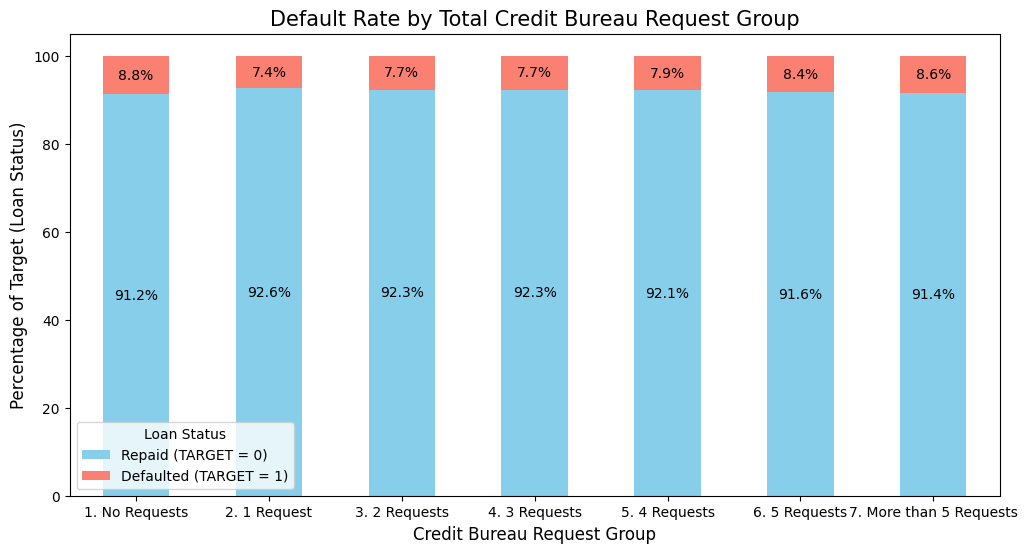

In [406]:
# Calculate the proportion of TARGET values for each TOTAL_CREDIT_BUREAU_REQUESTS Group
bureaurequest_target = cur_app.groupby(['BUREAU_REQUESTS_GROUP', 'TARGET']).size().unstack()
bureaurequest_target_percentage = bureaurequest_target.div(bureaurequest_target.sum(axis=1), axis=0) * 100

# Sort the index alphabetically
bureaurequest_target_percentage_sorted = bureaurequest_target_percentage.sort_index()

# Plot the 100% stacked column chart
label_request_tar = bureaurequest_target_percentage_sorted.plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])


# Add labels and title
plt.title('Default Rate by Total Credit Bureau Request Group', fontsize=15)
plt.xlabel('Credit Bureau Request Group', fontsize=12)
plt.ylabel('Percentage of Target (Loan Status)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Repaid (TARGET = 0)', 'Defaulted (TARGET = 1)'], title='Loan Status')

# Adding percentage data labels on bars 
for container in label_request_tar.containers:
    label_request_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\2402819373.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cur_app.loc[cur_app['TARGET'] == 0, source], label='Loans Repaid (TARGET = 0)', shade=True)
C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\2402819373.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cur_app.loc[cur_app['TARGET'] == 1, source], label='Loans Defaulted (TARGET = 1)', shade=True)
C:\Users\ThinkBook X-AI\AppData\Local\Temp\ipykernel_6100\2402819373.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cur_app.loc[cur_app['TARGET'] == 0, source], label='Loans Repaid (TARGET = 0)

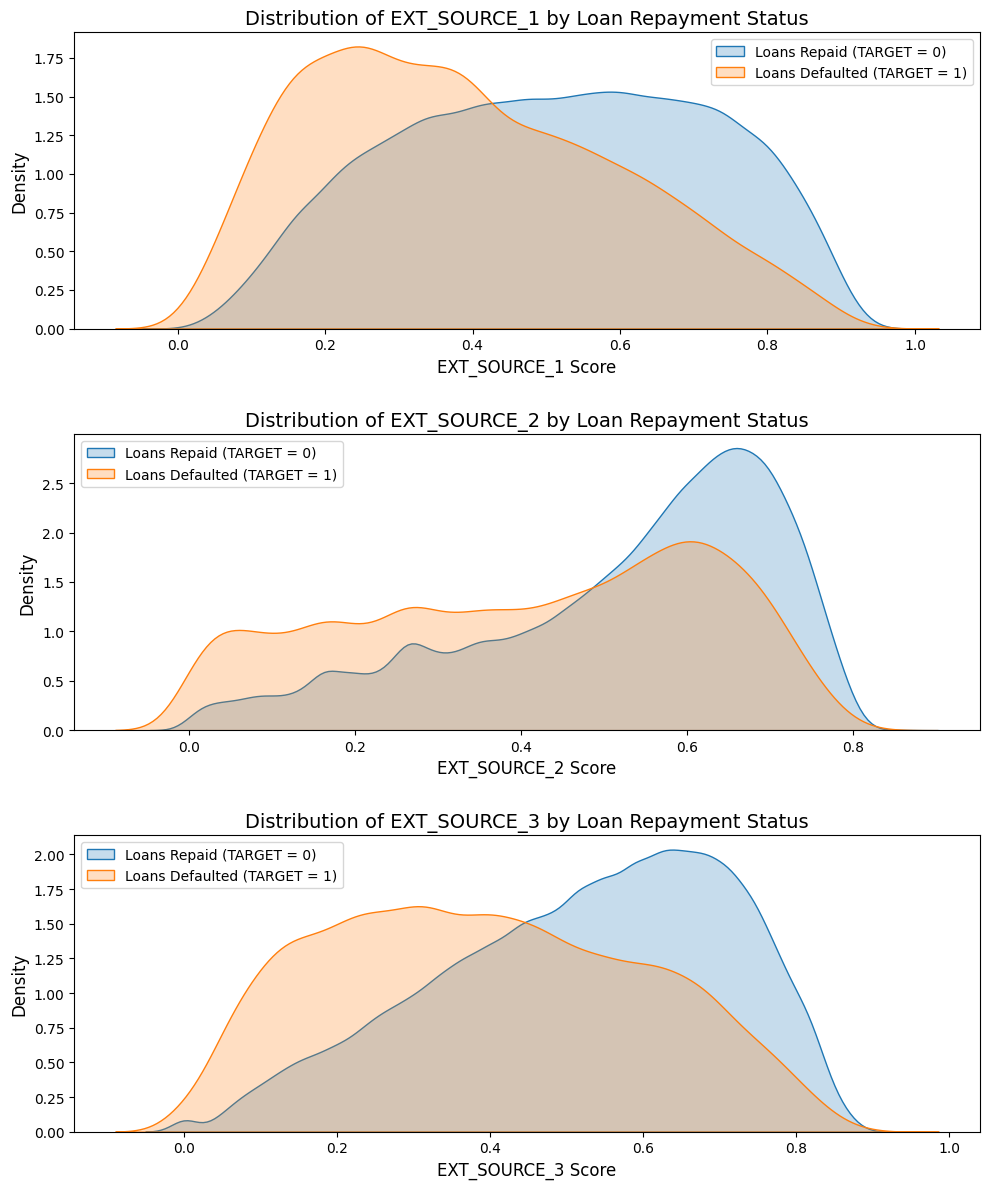

In [407]:
# Analyzing the impact of external scores on loan repayment
plt.figure(figsize=(10, 12))

# Loop through each external score feature to analyze its impact
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    # Set up a subplot for each external source
    plt.subplot(3, 1, i + 1)
    # Plot the distribution of the scores for clients who successfully repaid their loans
    sns.kdeplot(cur_app.loc[cur_app['TARGET'] == 0, source], label='Loans Repaid (TARGET = 0)', shade=True)
    # Plot the distribution for clients who defaulted on their loans
    sns.kdeplot(cur_app.loc[cur_app['TARGET'] == 1, source], label='Loans Defaulted (TARGET = 1)', shade=True)

    # Set titles and labels for each plot
    plt.title(f'Distribution of {source} by Loan Repayment Status', fontsize=14)
    plt.xlabel(f'{source} Score', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()

# Tight layout to enhance spacing between subplots
plt.tight_layout(h_pad=2.5)
plt.show()

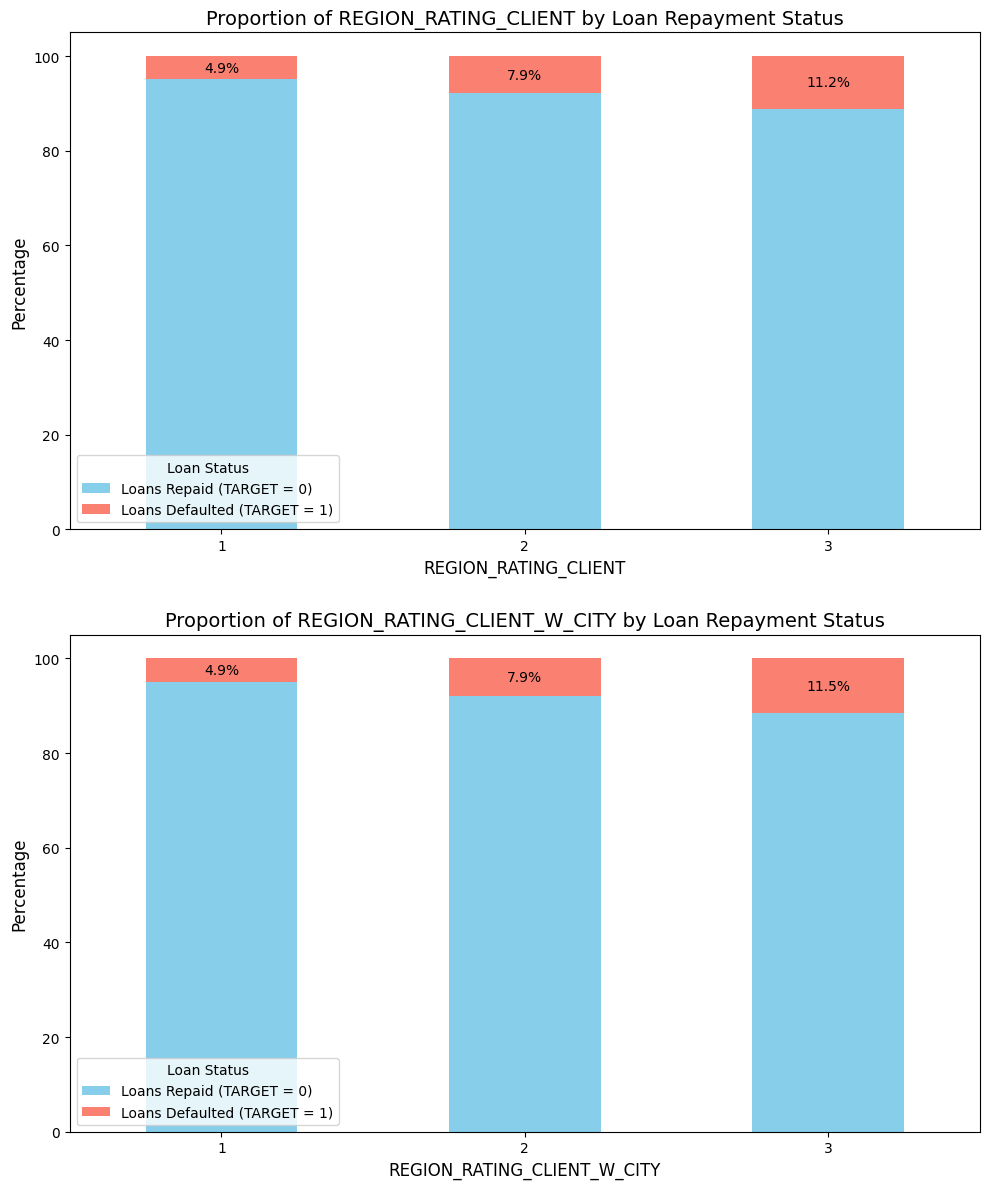

In [408]:
# Analyzing the impact of REGION_RATING_CLIENT and REGION_RATING_CLIENT_W_CITY on loan repayment
plt.figure(figsize=(10, 12))

# List of region rating columns
region_rating_columns = ['REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']

# Loop through each region rating feature to analyze its impact
for i, rating_col in enumerate(region_rating_columns):
    # Set up a subplot for each region rating
    plt.subplot(2, 1, i + 1)
    
    # Calculate the percentage of each rating grouped by TARGET (loan repayment status)
    rating_target = cur_app.groupby([rating_col, 'TARGET']).size().unstack().fillna(0)
    rating_target_percentage = rating_target.div(rating_target.sum(axis=1), axis=0) * 100

    # Plot the 100% stacked bar chart for each rating
    label_rat_tar = rating_target_percentage.plot(kind='bar', stacked=True, ax=plt.gca(), color=['skyblue', 'salmon'])
    
    # Set titles and labels for each plot
    plt.title(f'Proportion of {rating_col} by Loan Repayment Status', fontsize=14)
    plt.xlabel(f'{rating_col}', fontsize=12)
    plt.ylabel('Percentage', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(['Loans Repaid (TARGET = 0)', 'Loans Defaulted (TARGET = 1)'], title='Loan Status')
    
    # Adding percentage data labels for the bars representing defaulted loans (TARGET = 1)
    for container in label_rat_tar.containers:
        # Only add labels for 'Defaulted' (TARGET = 1) bars, which are the second container in each stack
        if container is label_rat_tar.containers[1]:
            label_rat_tar.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10, color='black')

# Tight layout to enhance spacing between subplots
plt.tight_layout(h_pad=2.5)
plt.show()



In [409]:
# Columns to be used for correlation analysis
selected_columns = [
    'MONTHLYCREDIT_INCOME_RATIO', 'YEARS_EMPLOYED', 'AGE',
    'TENOR', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
    'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_3',
    'REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY'
]

# Filter the DataFrame to only include these columns
filtered_df = cur_app[selected_columns]


# Function to get the top correlations from a DataFrame
def get_top_correlations(df, n=10):
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=['number'])
    
    # Calculate the correlation matrix
    correlation_matrix = numeric_df.corr().abs()  # Take the absolute value
    np.fill_diagonal(correlation_matrix.values, 0)  # Set diagonal to zero to exclude self-correlation

    # Unstack the matrix, sort, and get the top correlations
    sorted_correlations = correlation_matrix.unstack().sort_values(ascending=False)
    top_correlations = sorted_correlations.drop_duplicates().nlargest(n)
    
    return top_correlations

# Get top 10 correlations for clients with payment difficulties
clients_with_difficulties = cur_app[cur_app['TARGET'] == 1]
filtered_df_with_difficulties = clients_with_difficulties[selected_columns]
filtered_df_with_difficulties_encoded = pd.get_dummies(filtered_df_with_difficulties, drop_first=True)
top_correlations_with_difficulties = get_top_correlations(filtered_df_with_difficulties_encoded, 10)

# Get top 10 correlations for clients without payment difficulties
clients_without_difficulties = cur_app[cur_app['TARGET'] == 0]
filtered_df_without_difficulties = clients_without_difficulties[selected_columns]
filtered_df_without_difficulties_encoded = pd.get_dummies(filtered_df_without_difficulties, drop_first=True)
top_correlations_without_difficulties = get_top_correlations(filtered_df_without_difficulties_encoded, 10)

# Display the results
print("Top 10 correlations for clients with payment difficulties:")
print(top_correlations_with_difficulties)

print("\nTop 10 correlations for clients without payment difficulties:")
print(top_correlations_without_difficulties)


Top 10 correlations for clients with payment difficulties:
REGION_RATING_CLIENT    REGION_RATING_CLIENT_W_CITY    0.956598
REG_CITY_NOT_WORK_CITY  LIVE_CITY_NOT_WORK_CITY        0.778643
YEARS_EMPLOYED          AGE                            0.653847
AGE                     EXT_SOURCE_1                   0.571782
REG_CITY_NOT_LIVE_CITY  REG_CITY_NOT_WORK_CITY         0.470774
EXT_SOURCE_1            YEARS_EMPLOYED                 0.364900
YEARS_EMPLOYED          REG_CITY_NOT_WORK_CITY         0.270517
AGE                     TENOR                          0.213860
                        REG_CITY_NOT_WORK_CITY         0.213195
YEARS_EMPLOYED          LIVE_CITY_NOT_WORK_CITY        0.205511
dtype: float64

Top 10 correlations for clients without payment difficulties:
REGION_RATING_CLIENT     REGION_RATING_CLIENT_W_CITY    0.949879
REG_CITY_NOT_WORK_CITY   LIVE_CITY_NOT_WORK_CITY        0.830161
YEARS_EMPLOYED           AGE                            0.699370
AGE                      EXT

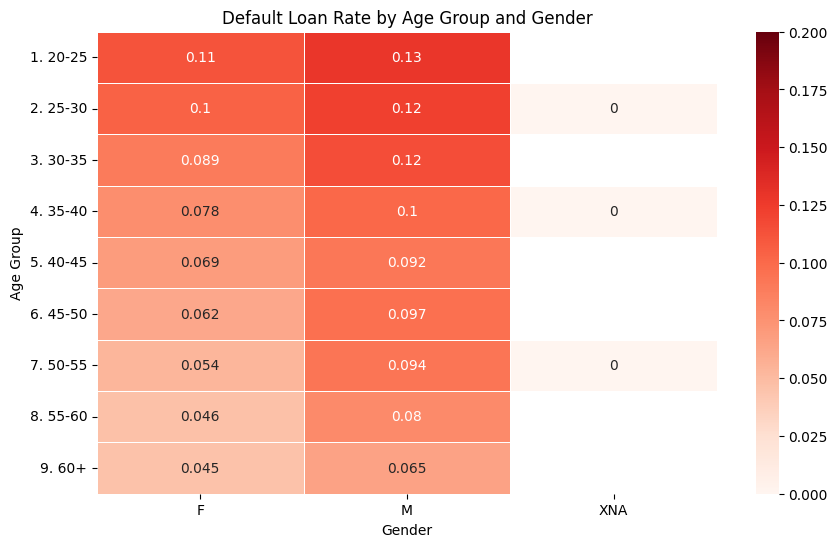

In [410]:
# Check the correlation between age and gender
crosstab = pd.crosstab(index=[cur_app['AGE_GROUP'], cur_app['CODE_GENDER']], 
                       columns=cur_app['TARGET'], 
                       normalize='index')

# Create a pivot table for better visualization in the heatmap
crosstab.reset_index(inplace=True)
heatmap_data = crosstab.pivot(index='AGE_GROUP', columns='CODE_GENDER', values=1)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', linewidths=0.5, vmin=0, vmax=0.2)

# Add labels and title
plt.title('Default Loan Rate by Age Group and Gender')
plt.xlabel('Gender')
plt.ylabel('Age Group')
plt.show()

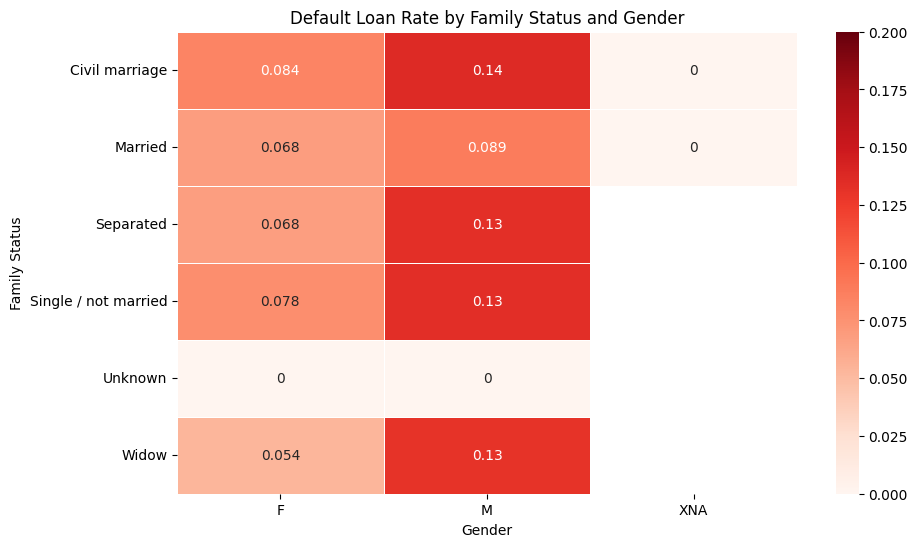

In [418]:
 
# Check the correlation between family status and gender
crosstab = pd.crosstab(index=[cur_app['NAME_FAMILY_STATUS'], cur_app['CODE_GENDER']], 
                       columns=cur_app['TARGET'], 
                       normalize='index')

# Create a pivot table for better visualization in the heatmap
crosstab.reset_index(inplace=True)
heatmap_data = crosstab.pivot(index='NAME_FAMILY_STATUS', columns='CODE_GENDER', values=1)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', linewidths=0.5, vmin=0, vmax=0.2)

# Add labels and title
plt.title('Default Loan Rate by Family Status and Gender')
plt.xlabel('Gender')
plt.ylabel('Family Status')
plt.show()

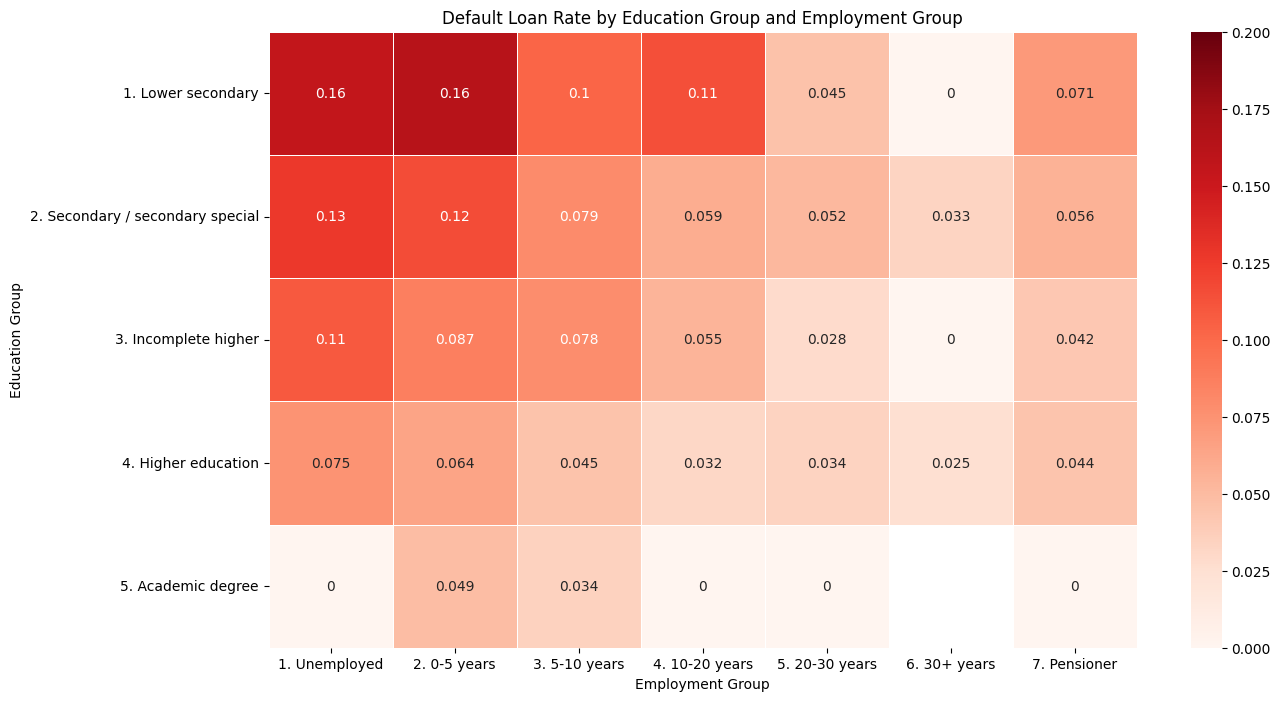

In [ ]:
# Check the correlation between education and employment group
crosstab = pd.crosstab(index=[cur_app['NAME_EDUCATION_TYPE'], cur_app['EMPLOYMENT_GROUP']], 
                       columns=cur_app['TARGET'], 
                       normalize='index')

# Create a pivot table for better visualization in the heatmap
crosstab.reset_index(inplace=True)
heatmap_data = crosstab.pivot(index='NAME_EDUCATION_TYPE', columns='EMPLOYMENT_GROUP', values=1)

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', linewidths=0.5, vmin=0, vmax=0.2)

# Add labels and title
plt.title('Default Loan Rate by Education Group and Employment Group')
plt.xlabel('Employment Group')
plt.ylabel('Education Group')
plt.show()

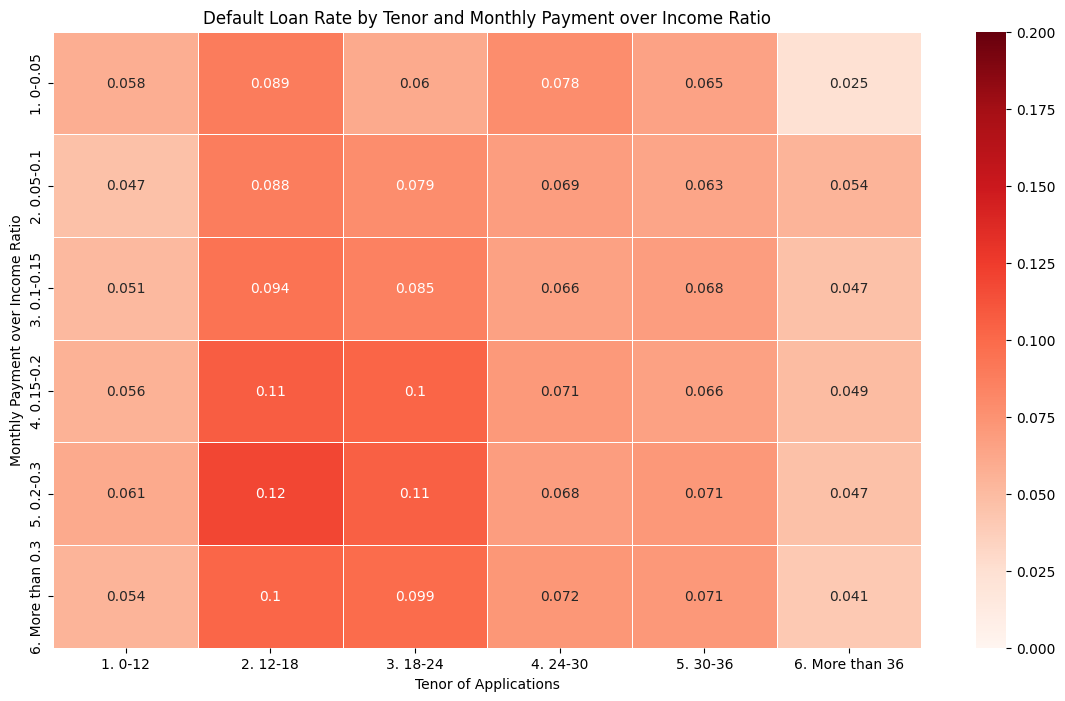

In [412]:
# Check the correlation between monthly credit to income ratio and tenor of application
crosstab = pd.crosstab(index=[cur_app['MONTHLYCREDIT_INCOME_RATIO_GROUP'], cur_app['TENOR_GROUP']], 
                       columns=cur_app['TARGET'], 
                       normalize='index')

# Create a pivot table for better visualization in the heatmap
crosstab.reset_index(inplace=True)
heatmap_data = crosstab.pivot(index='MONTHLYCREDIT_INCOME_RATIO_GROUP', columns='TENOR_GROUP', values=1)

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', linewidths=0.5, vmin=0, vmax=0.2)

# Add labels and title
plt.title('Default Loan Rate by Tenor and Monthly Payment over Income Ratio')
plt.xlabel('Tenor of Applications')
plt.ylabel('Monthly Payment over Income Ratio')
plt.show()

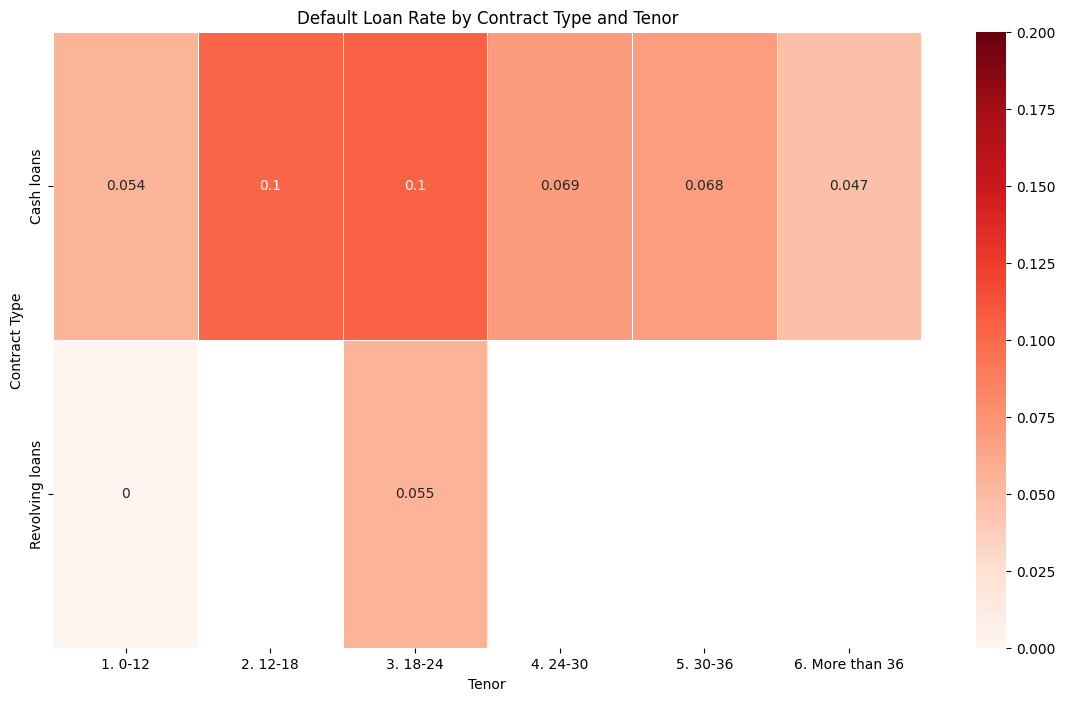

In [419]:
# Check the correlation between tenor and contract type of application
crosstab = pd.crosstab(index=[cur_app['NAME_CONTRACT_TYPE'], cur_app['TENOR_GROUP']], 
                       columns=cur_app['TARGET'], 
                       normalize='index')

# Create a pivot table for better visualization in the heatmap
crosstab.reset_index(inplace=True)
heatmap_data = crosstab.pivot(index='NAME_CONTRACT_TYPE', columns='TENOR_GROUP', values=1)

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', linewidths=0.5, vmin=0, vmax=0.2)

# Add labels and title
plt.title('Default Loan Rate by Contract Type and Tenor')
plt.xlabel('Tenor')
plt.ylabel('Contract Type')
plt.show()

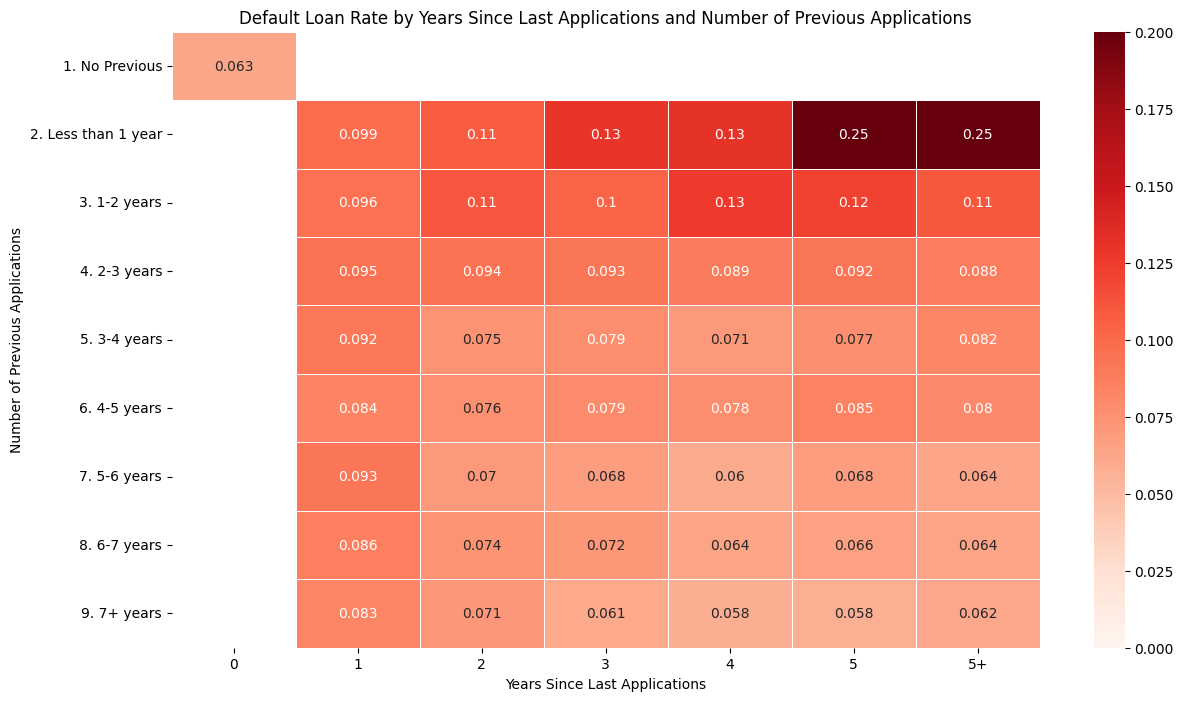

In [ ]:
# Check the correlation between number of previous applications and years since last applications
crosstab = pd.crosstab(index=[cur_app['PREAPP_GROUP'], cur_app['YEARS_SINCE_PREV_DECISION_GROUP']], 
                       columns=cur_app['TARGET'], 
                       normalize='index')

# Create a pivot table for better visualization in the heatmap
crosstab.reset_index(inplace=True)
heatmap_data = crosstab.pivot(index='YEARS_SINCE_PREV_DECISION_GROUP', columns='PREAPP_GROUP', values=1)

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', linewidths=0.5, vmin=0, vmax=0.2)

# Add labels and title
plt.title('Default Loan Rate by Years Since Last Applications and Number of Previous Applications')
plt.xlabel('Number of Previous Applications')
plt.ylabel('Years Since Last Applications')
plt.show()